In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
import results_analysis_utils as rutils
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
pd.set_option('display.max_columns', 100)

# EXECUTE COPY TO LOCAL DISK PRIMER!!!!!

%load_ext autoreload
%autoreload 2

# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200 
plt.rcParams['savefig.dpi'] = 200

# ===================================================================
# 1. DICCIONARIOS DE GROUND TRUTH
# ===================================================================

peix_measures = {
    "lubina0": 31.5, "fish_1": 19.4, "caballa": 28.9, "fish_3": 21.6,
    "llobarro": 33.5, "ochoa_no_cinta": 30.5, "ochoa_cinta": 33.5, 
    "ochoa_petita": 30.5, "llobarro_vermell": 29.1, "error": -100, "None": -100,
    "red":29.1, "black":26.6, "no_mark":32.3
}

reverse_peix_measures = {v: k for k, v in peix_measures.items()}


# Ruta base donde están todas las carpetas de días


# Carpeta SOLO para los resultados globales (se crea si no existe)

global_single_dfs = []
global_multi_dfs = []


single_fish_gt = {
    "2024_11_12": 31.5, "2024_11_28": 28.9, 
    "2025_05_08": 33.5, "2025_08_21": 29.1
}

multiple_fish_gt = {
    "2024_11_28": {
        '13-14-43_0': {1: "caballa", 21: "fish_3", 24: "caballa", 29: "fish_3", 37: "caballa", 45: "caballa", 58: "fish_3", 62: "fish_3", 75: "fish_3", 77: "fish_3", 81: "fish_3", 82: "fish_3"},
        '13-16-54_0': {1: "caballa", 12: "fish_3", 17: "fish_3", 29: "fish_3", 41: "caballa", 49: "caballa", 53: "caballa", 59: "fish_3", 67: "fish_3", 68: "fish_3", 70: "caballa", 71: "fish_3"},
        '13-27-52_0': {1: "caballa", 2: "fish_3", 3: "fish_3", 5: "fish_3", 6: "fish_3", 8: "fish_3", 11: "caballa", 12: "fish_3", 13: "fish_3", 33: "caballa", 35: "error", 37: "caballa"},
        '13-32-16_0': {1: "fish_3", 4: "caballa", 6: "caballa", 17: "fish_3", 25: "caballa", 28: "caballa", 30: "caballa", 44: "caballa", 52: "caballa", 53: "caballa", 67: "caballa"},
        '13-34-27_0': {1: "caballa", 5: "caballa", 8: "caballa", 16: "caballa", 21: "caballa", 23: "fish_3", 28: "caballa", 30: "error", 31: "caballa"},
        '13-36-49_0': {1: "fish_3", 2: "caballa", 3: "fish_3", 6: "fish_3", 10: "fish_3", 11: "fish_3", 19: "fish_3", 20: "caballa", 24: "fish_3", 30: "caballa", 33: "fish_3", 40: "error", 41: "error", 42: "error"},
        '13-39-00_0': {1: "error", 2: "caballa", 8: "caballa", 11: "caballa", 12: "caballa", 23: "error"},
        '13-41-12_0': {2: "fish_3", 3: "caballa", 11: "caballa"},
        '13-42-45_0': {1: "caballa", 2: "fish_3", 5: "caballa", 17: "caballa", 26: "caballa"},
        '13-48-24_0': {1: "caballa", 4: "fish_3", 5: "fish_3", 10: "fish_3"},
        '13-49-20_0': {1: "caballa", 2: "fish_3", 9: "fish_3", 13: "caballa", 16: "fish_3", 25: "caballa", 29: "fish_3", 32: "fish_3", 34: "fish_3", 36: "fish_3", 41: "fish_3", 44: "fish_1", 56: "fish_1", 58: "fish_3", 60: "fish_1", 61: "fish_3", 64: "fish_3", 69: "fish_1", 72: "fish_1", 73: "caballa", 75: "fish_1", 76: "fish_1", 77: "fish_1"}
        
        # PENDING !!!!
        # "13-14-43_0": {23: "None", 30: "None", 33: "None", 38: "None", 61: "None"},
        # "13-16-54_0": {5: "None", 7: "None", 13: "None", 19: "None", 55: "None"},
        # "13-27-52_0": {4: "None", 30: "None"},
        # "13-32-16_0": {35: "None"},
        # "13-36-49_0": {7: "None"},
        # "13-39-00_0": {13: "None"},
        # "13-41-12_0": {14: "None"},
        # "13-42-45_0": {8: "None"},
        # "13-49-20_0": {17: "None"},
        # "13-52-04_0": {1: "None", 2: "None", 4: "None", 9: "None", 11: "None", 14: "None", 21: "None", 23: "None", 25: "None", 27: "None", 28: "None", 32: "None", 34: "None", 36: "None", 38: "None", 40: "None", 44: "None", 46: "None", 53: "None", 56: "None"},
        # "13-54-15_0": {1: "None", 2: "None", 3: "None", 8: "None", 9: "None", 11: "None", 17: "None", 18: "None", 23: "None", 29: "None", 30: "None", 31: "None", 35: "None", 37: "None", 38: "None", 39: "None", 41: "None", 42: "None"},
        # "13-56-44_0": {1: "None", 2: "None", 3: "None", 4: "None", 11: "None", 13: "None", 14: "None", 16: "None", 17: "None", 20: "None"},
        # "13-58-56_0": {1: "None", 2: "None", 3: "None", 5: "None"}
    
    
    },
    "2025_05_08": {
        '11-28-42_0': {1: "ochoa_petita", 2: "llobarro", 5: "ochoa_petita"},
        '11-29-16_1': {1: "llobarro", 2: "ochoa_petita", 6: "ochoa_petita", 8: "ochoa_petita"},
        '11-29-49_2': {1: "ochoa_petita", 2: "llobarro", 6: "ochoa_petita", 7: "ochoa_petita"},
        '11-30-34_0': {1: "ochoa_petita", 6: "llobarro"},
        '11-31-08_1': {1: "llobarro", 2: "ochoa_petita", 3: "ochoa_petita", 8: "ochoa_petita"},
        '11-33-23_0': {1: "llobarro", 2: "ochoa_petita", 10: "ochoa_petita", 18: "llobarro", 19: "ochoa_petita", 20: "ochoa_petita"},
        '11-33-52_1': {1: "llobarro", 2: "ochoa_petita", 4: "llobarro"},
        '11-36-36_0': {1: "llobarro", 2: "ochoa_petita", 8: "llobarro", 13: "ochoa_petita", 23: "ochoa_petita", 27: "ochoa_petita", 30: "llobarro"}, 
        '11-37-20_1': {1: "error", 2: "llobarro", 8: "ochoa_petita", 16: "llobarro", 18: "ochoa_petita", 25: "ochoa_petita", 33: "ochoa_petita", 34: "ochoa_petita"},
        '11-41-45_0': {1: "llobarro", 8: "llobarro"},
        '11-42-15_1': {1: "llobarro"},
        '11-44-48_0': {1: "llobarro", 3: "ochoa_petita", 6: "ochoa_petita", 7: "ochoa_petita", 10: "error"},
        '11-48-15_0': {1: "llobarro", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 6: "ochoa_cinta", 13: "ochoa_cinta", 14: "llobarro", 16: "ochoa_no_cinta", 18: "ochoa_cinta", 19: "ochoa_cinta", 22: "ochoa_cinta"},
        '11-49-52_0': {1: "llobarro", 3: "ochoa_no_cinta", 4: "ochoa_cinta", 7: "ochoa_cinta", 10: "llobarro", 13: "ochoa_no_cinta", 14: "ochoa_cinta"},
        '11-57-17_0': {1: "llobarro", 2: "ochoa_cinta", 4: "ochoa_no_cinta"},
        '11-57-59_0': {1: "ochoa_no_cinta", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 9: "llobarro", 10: "llobarro", 16: "ochoa_no_cinta", 20: "ochoa_cinta", 24: "llobarro"},
        '11-59-57_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 8: "llobarro", 14: "llobarro", 20: "ochoa_no_cinta", 24: "llobarro"},
        '12-00-39_0': {1: "ochoa_cinta", 2: "llobarro", 3: "ochoa_no_cinta", 14: "ochoa_cinta", 17: "ochoa_no_cinta", 29: "ochoa_no_cinta", 34: "ochoa_no_cinta", 36: "ochoa_no_cinta", 39: "ochoa_no_cinta"},
        '12-01-20_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 3: "llobarro", 4: "ochoa_no_cinta", 5: "llobarro", 9: "ochoa_no_cinta", 13: "ochoa_cinta", 26: "llobarro", 29: "ochoa_cinta", 33: "ochoa_cinta"},
        '12-02-02_0': {1: "ochoa_cinta", 2: "ochoa_no_cinta", 3: "llobarro", 9: "ochoa_no_cinta", 11: "ochoa_cinta", 13: "ochoa_cinta", 16: "ochoa_no_cinta"},
        '12-02-44_0': {1: "llobarro", 2: "ochoa_no_cinta", 3: "ochoa_cinta", 11: "ochoa_cinta", 13: "ochoa_no_cinta"}
    },
    "2025_08_21": {
        "10-01-53_0_compressed-r201-end": {-1: "None", 1: "red", 3: "no_mark", 4: "no_mark", 10: "red", 
                                           11: "red", 13: "no_mark", 18: "red", 19: "no_mark", 20: "None", 
                                           31: "no_mark", 32: "red"},
        
        "10-07-59_0-r50-end": {-1: "None", 1: "no_mark", 2: "red", 3: "no_mark", 
                               5: "no_mark", 6: "red", 9: "no_mark", 12: "no_mark", 
                               13: "None", 14: "None", 15: "red", 16: "red", 
                               18: "red", 19: "red", 20: "red", 21: "no_mark", 
                               22: "None", 24: "red", 27: "no_mark", 28: "red"},
                
        "10-09-31_0-r0-344": {1: "no_mark", 4: "red", 5: "no_mark", 7: "no_mark", 8: "None", 
                              9: "red", 10: "no_mark", 12: "no_mark", 16: "red", 17: "no_mark"},

        "10-09-31_0-r398-end": {-1: "None", 1: "red", 2: "no_mark", 4: "no_mark", 
                                5: "no_mark", 7: "red", 8: "no_mark", 9: "no_mark", 
                                12: "red", 13: "red", 14: "red"},
    
        "10-11-02_0-r0-244": {-1: "None", 1: "no_mark", 2: "red", 
                              3: "red", 7: "no_mark", 9: "None", 14: "red"},
    
        "10-11-02_0-r295-end": {1: "red", 2: "no_mark", 4: "red", 
                                8: "None", 10: "red", 14: "no_mark"},

        "10-12-34_0-r215-end": {1: "red", 2: "red", 4: "no_mark", 
                                6: "red", 7: "None", 10: "red", 
                                12: "red", 14: "None", 15: "no_mark"},
        "10-14-05_0-r0-528": {-1: "None", 1: "red", 2: "no_mark", 6: "red", 
                              9: "no_mark", 10: "red", 12: "None", 13: "no_mark", 
                              15: "None", 16: "None", 17: "no_mark", 18: "red"},
        
        "10-15-37_0-r496-end": {1: "no_mark", 2: "red", 5: "red", 6: "no_mark"},
        "10-18-24_0_compressed-r47-end": {-1: "None", 1: "red", 5: "no_mark", 
                                          7: "no_mark", 10: "red", 11: "None", 
                                          12: "red", 17: "red", 18: "red"},
        "10-19-44_0_compressed-r383-534": {1: "no_mark", 2: "red"},
        "10-19-44_0_compressed-r588-end": {1: "red", 2: "no_mark"},
        "10-20-29_1_compressed-r0-78": {-1: "None", 1: "red", 
                                        2: "no_mark", 3: "no_mark", 4: "red"},
        "10-22-00_1_compressed": {-1: "None", 1: "red", 2: "no_mark",
                                  3: "red", 5: "None"},
        "10-37-15_1-r": {-1: "None", 1: "no_mark", 2: "red", 
                         3: "red", 6: "red", 8: "no_mark", 9: "error", 10: "error"},
        "13-05-55_0-r": {1: "red", 2: "no_mark", 3: "black", 4: "black", 5: "no_mark", 
                         8: "black", 10: "red", 11: "None", 15: "black", 20: "red", 
                         22: "None", 25: "None", 26: "no_mark", 27: "None", 28: "no_mark", 
                         30: "no_mark", 34: "no_mark", 38: "red", 39: "None", 42: "red", 
                         47: "no_mark", 49: "black"},
        "13-22-22_0_compressed-r60-297": {1: "no_mark", 2: "black", 3: "red", 6: "red", 
                                          7: "None", 9: "red", 11: "None", 13: "black"},
        "13-22-22_0_compressed-r378-463": {1: "black", 2: "no_mark", 3: "red", 4: "error"},
        "13-23-54_0_compressed-r0-304": {-1: "None", 2: "red", 3: "black", 5: "no_mark"},
        "13-23-54_0_compressed-r450-524": {1: "no_mark", 2: "black", 3: "red", 5: "None"},
        "13-23-54_0_compressed-r602-end": {1: "red", 2: "black", 3: "no_mark"}
    }
     
}


# multiple_fish_gt = {
#     "2024_11_28": {
#         '13-14-43_0': {1: "caballa", 21: "fish_3", 24: "caballa", 29: "fish_3", 37: "caballa", 45: "caballa", 58: "fish_3", 62: "fish_3", 75: "fish_3", 77: "fish_3", 81: "fish_3", 82: "fish_3"},
#         '13-16-54_0': {1: "caballa", 12: "fish_3", 17: "fish_3", 29: "fish_3", 41: "caballa", 49: "caballa", 53: "caballa", 59: "fish_3", 67: "fish_3", 68: "fish_3", 70: "caballa", 71: "fish_3"},
#         '13-27-52_0': {1: "caballa", 2: "fish_3", 3: "fish_3", 5: "fish_3", 6: "fish_3", 8: "fish_3", 11: "caballa", 12: "fish_3", 13: "fish_3", 33: "caballa", 35: "error", 37: "caballa"},
#         '13-32-16_0': {1: "fish_3", 4: "caballa", 6: "caballa", 17: "fish_3", 25: "caballa", 28: "caballa", 30: "caballa", 44: "caballa", 52: "caballa", 53: "caballa", 67: "caballa"},
#         '13-34-27_0': {1: "caballa", 5: "caballa", 8: "caballa", 16: "caballa", 21: "caballa", 23: "fish_3", 28: "caballa", 30: "error", 31: "caballa"},
#         '13-36-49_0': {1: "fish_3", 2: "caballa", 3: "fish_3", 6: "fish_3", 10: "fish_3", 11: "fish_3", 19: "fish_3", 20: "caballa", 24: "fish_3", 30: "caballa", 33: "fish_3", 40: "error", 41: "error", 42: "error"},
#         '13-39-00_0': {1: "error", 2: "caballa", 8: "caballa", 11: "caballa", 12: "caballa", 23: "error"},
#         '13-41-12_0': {2: "fish_3", 3: "caballa", 11: "caballa"},
#         '13-42-45_0': {1: "caballa", 2: "fish_3", 5: "caballa", 17: "caballa", 26: "caballa"},
#         '13-48-24_0': {1: "caballa", 4: "fish_3", 5: "fish_3", 10: "fish_3"},
#         '13-49-20_0': {1: "caballa", 2: "fish_3", 9: "fish_3", 13: "caballa", 16: "fish_3", 25: "caballa", 29: "fish_3", 32: "fish_3", 34: "fish_3", 36: "fish_3", 41: "fish_3", 44: "fish_1", 56: "fish_1", 58: "fish_3", 60: "fish_1", 61: "fish_3", 64: "fish_3", 69: "fish_1", 72: "fish_1", 73: "caballa", 75: "fish_1", 76: "fish_1", 77: "fish_1"}
#     },
#     "2025_05_08": {
#         '11-28-42_0': {1: "ochoa_petita", 2: "llobarro", 5: "ochoa_petita"},
#         '11-29-16_1': {1: "llobarro", 2: "ochoa_petita", 6: "ochoa_petita", 8: "ochoa_petita"},
#         '11-29-49_2': {1: "ochoa_petita", 2: "llobarro", 6: "ochoa_petita", 7: "ochoa_petita"},
#         '11-30-34_0': {1: "ochoa_petita", 6: "llobarro"},
#         '11-31-08_1': {1: "llobarro", 2: "ochoa_petita", 3: "ochoa_petita", 8: "ochoa_petita"},
#         '11-33-23_0': {1: "llobarro", 2: "ochoa_petita", 10: "ochoa_petita", 18: "llobarro", 19: "ochoa_petita", 20: "ochoa_petita"},
#         '11-33-52_1': {1: "llobarro", 2: "ochoa_petita", 4: "llobarro"},
#         '11-36-36_0': {1: "llobarro", 2: "ochoa_petita", 8: "llobarro", 13: "ochoa_petita", 23: "ochoa_petita", 27: "ochoa_petita", 30: "llobarro"}, 
#         '11-37-20_1': {1: "error", 2: "llobarro", 8: "ochoa_petita", 16: "llobarro", 18: "ochoa_petita", 25: "ochoa_petita", 33: "ochoa_petita", 34: "ochoa_petita"},
#         '11-41-45_0': {1: "llobarro", 8: "llobarro"},
#         '11-42-15_1': {1: "llobarro"},
#         '11-44-48_0': {1: "llobarro", 3: "ochoa_petita", 6: "ochoa_petita", 7: "ochoa_petita", 10: "error"},
#         '11-48-15_0': {1: "llobarro", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 6: "ochoa_cinta", 13: "ochoa_cinta", 14: "llobarro", 16: "ochoa_no_cinta", 18: "ochoa_cinta", 19: "ochoa_cinta", 22: "ochoa_cinta"},
#         '11-49-52_0': {1: "llobarro", 3: "ochoa_no_cinta", 4: "ochoa_cinta", 7: "ochoa_cinta", 10: "llobarro", 13: "ochoa_no_cinta", 14: "ochoa_cinta"},
#         '11-57-17_0': {1: "llobarro", 2: "ochoa_cinta", 4: "ochoa_no_cinta"},
#         '11-57-59_0': {1: "ochoa_no_cinta", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 9: "llobarro", 10: "llobarro", 16: "ochoa_no_cinta", 20: "ochoa_cinta", 24: "llobarro"},
#         '11-59-57_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 8: "llobarro", 14: "llobarro", 20: "ochoa_no_cinta", 24: "llobarro"},
#         '12-00-39_0': {1: "ochoa_cinta", 2: "llobarro", 3: "ochoa_no_cinta", 14: "ochoa_cinta", 17: "ochoa_no_cinta", 29: "ochoa_no_cinta", 34: "ochoa_no_cinta", 36: "ochoa_no_cinta", 39: "ochoa_no_cinta"},
#         '12-01-20_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 3: "llobarro", 4: "ochoa_no_cinta", 5: "llobarro", 9: "ochoa_no_cinta", 13: "ochoa_cinta", 26: "llobarro", 29: "ochoa_cinta", 33: "ochoa_cinta"},
#         '12-02-02_0': {1: "ochoa_cinta", 2: "ochoa_no_cinta", 3: "llobarro", 9: "ochoa_no_cinta", 11: "ochoa_cinta", 13: "ochoa_cinta", 16: "ochoa_no_cinta"},
#         '12-02-44_0': {1: "llobarro", 2: "ochoa_no_cinta", 3: "ochoa_cinta", 11: "ochoa_cinta", 13: "ochoa_no_cinta"}
#     },
#     "2025_08_21": {
#         "10-01-53_0_compressed-r201-end": {-1: "None", 1: "red", 3: "no_mark", 4: "no_mark", 10: "red", 11: "red", 13: "no_mark", 18: "red", 19: "no_mark", 20: "None", 31: "no_mark", 32: "red"},
#         "10-07-59_0-r50-end": {-1: "None", 1: "no_mark", 2: "red", 3: "no_mark", 5: "no_mark", 6: "red", 9: "no_mark", 12: "no_mark", 13: "None", 14: "None", 15: "red", 16: "red", 18: "red", 19: "red", 20: "red", 21: "no_mark", 22: "None", 24: "red", 27: "no_mark", 28: "red"},
#         "10-09-31_0-r0-344": {1: "no_mark", 4: "red", 5: "no_mark", 7: "no_mark", 8: "None", 9: "red", 10: "no_mark", 12: "no_mark", 16: "red", 17: "no_mark"},
#         "10-09-31_0-r398-end": {-1: "None", 1: "red", 2: "no_mark", 4: "no_mark", 5: "no_mark", 7: "red", 8: "no_mark", 9: "no_mark", 12: "red", 13: "red", 14: "red"},
#         "10-11-02_0-r0-244": {-1: "None", 1: "no_mark", 2: "red", 3: "red", 7: "no_mark", 9: "None", 14: "red"},
#         "10-11-02_0-r295-end": {1: "red", 2: "no_mark", 4: "red", 8: "None", 10: "red", 14: "no_mark"},
#         "10-12-34_0-r215-end": {1: "red", 2: "red", 4: "no_mark", 6: "red", 7: "None", 10: "red", 12: "red", 14: "None", 15: "no_mark"},
#         "10-14-05_0-r0-528": {-1: "None", 1: "red", 2: "no_mark", 6: "red", 9: "no_mark", 10: "red", 12: "None", 13: "no_mark", 15: "None", 16: "None", 17: "no_mark", 18: "red"},
#         "10-15-37_0-r496-end": {1: "no_mark", 2: "red", 5: "red", 6: "no_mark"},
#         "10-18-24_0_compressed-r47-end": {-1: "None", 1: "red", 5: "no_mark", 7: "no_mark", 10: "red", 11: "None", 12: "red", 17: "red", 18: "red"},
#         "10-19-44_0_compressed-r383-534": {1: "no_mark", 2: "red"},
#         "10-19-44_0_compressed-r588-end": {1: "red", 2: "no_mark"},
#         "10-20-29_1_compressed-r0-78": {-1: "None", 1: "red", 2: "no_mark", 3: "no_mark", 4: "red"},
#         "10-22-00_1_compressed": {-1: "None", 1: "red", 2: "no_mark", 3: "red", 5: "None"},
#         "10-37-15_1-r": {-1: "None", 1: "no_mark", 2: "red", 3: "red", 6: "red", 8: "no_mark", 9: "error", 10: "error"},
#         "13-05-55_0-r": {1: "red", 2: "no_mark", 3: "black", 4: "black", 5: "no_mark", 8: "black", 10: "red", 11: "None", 15: "black", 20: "red", 22: "None", 25: "None", 26: "no_mark", 27: "None", 28: "no_mark", 30: "no_mark", 34: "no_mark", 38: "red", 39: "None", 42: "red", 47: "no_mark", 49: "black"},
#         "13-22-22_0_compressed-r60-297": {1: "no_mark", 2: "black", 3: "red", 6: "red", 7: "None", 9: "red", 11: "None", 13: "black"},
#         "13-22-22_0_compressed-r378-463": {1: "black", 2: "no_mark", 3: "red", 4: "error"},
#         "13-23-54_0_compressed-r0-304": {-1: "None", 2: "red", 3: "black", 5: "no_mark"},
#         "13-23-54_0_compressed-r450-524": {1: "no_mark", 2: "black", 3: "red", 5: "None"},
#         "13-23-54_0_compressed-r602-end": {1: "red", 2: "black", 3: "no_mark"}
#     }
# }

ALL_DAYS = list(set(list(single_fish_gt.keys()) + list(multiple_fish_gt.keys())))
ASPECT_RATIO_THR = 3
ANGLE_THR = 25.0

# ===================================================================
# 2. MASTER LOOP: ITERATE OVER BOTH DATASETS
# ===================================================================

for dataset_id in ["DATASET_1", "DATASET_2"]:
    cprint(f"\n\n{'='*70}", "white", "on_green", attrs=["bold"])
    cprint(f"🚀 STARTING AGGREGATION FOR: {dataset_id}", "white", "on_green", attrs=["bold"])
    cprint(f"{'='*70}", "white", "on_green", attrs=["bold"])
    
    BASE_DIR = Path(f"/home/slimbook/fish_sizing/ARTICLE/{dataset_id}")
    OUTPUT_DIR_GLOBAL = BASE_DIR / "aggregated_data"
    os.makedirs(OUTPUT_DIR_GLOBAL, exist_ok=True)
    
    global_single_dfs = []
    global_multi_dfs = []

    for day_code in sorted(ALL_DAYS):
        day_folder = BASE_DIR / day_code
        
        # MAGIC HERE: If the day doesn't belong to this dataset, it is automatically skipped.
        if not day_folder.exists():
            continue

        cprint(f"\n" + "-"*50, "cyan")
        cprint(f"📅 PROCESSING DAY: {day_code} in {dataset_id}", "cyan", attrs=["bold"])
        
        day_dfs = []

        # ---------------------------------------------------------------
        # A) PROCESS SINGLE FISH
        # ---------------------------------------------------------------
        dir_single = day_folder / "single_fish"
        
        if dir_single.exists() and day_code in single_fish_gt:
            cprint(f"\n🐟 Looking for SINGLE FISH...", "magenta")
            # Use the correct folder name for your case (assuming "results" for single fish too)
            df_single = rutils.aggregate_results_from_root_new(dir_single, day_code, output_csv_path=dir_single, results_foldername="results")
            
            if not df_single.empty:
                medida = single_fish_gt[day_code]
                especie = reverse_peix_measures.get(medida, "unknown_single_fish")
                
                df_single["gt"] = medida
                df_single["especie_gt"] = especie
                df_single["abs_error_cm"] = abs((df_single["filtered_length"] * 100) - medida)
                df_single["failure_reason"] = np.nan
                df_single['unique_track'] = df_single['video_day'].astype(str) + "/" + df_single['video_name'].astype(str) + "/" + df_single['track_id'].astype(str)
                df_single["scenario"] = "single_fish"
                
                df_single = rutils.assign_failure_reasons(df_single, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
                
                out_single = dir_single / f"{day_code}_single_fish_agg.csv"
                df_single.to_csv(out_single, index=False)
                
                global_single_dfs.append(df_single)
                day_dfs.append(df_single) 
                cprint(f"   ✅ Single Fish completed.", "green")
        else:
            if not dir_single.exists():
                cprint(f"   ℹ️ No 'single_fish' folder for this day.", "dark_grey")
        
        # ---------------------------------------------------------------
        # B) PROCESS MULTIPLE FISH
        # ---------------------------------------------------------------
        dir_multi = day_folder / "multiple_fish"  
        
        if dir_multi.exists() and day_code in multiple_fish_gt:
            cprint(f"\n🐠🐠 Looking for MULTIPLE FISH...", "magenta")
            df_multi_raw = rutils.aggregate_results_from_root_new(dir_multi, day_code, output_csv_path=dir_multi, results_foldername="results")
            
            if not df_multi_raw.empty:
                df_multi_raw['track_id'] = pd.to_numeric(df_multi_raw['track_id'], errors='coerce').fillna(-1).astype(int)
                
                df_multi, huerfanos = rutils.inject_ground_truth(
                    df_multi_raw, 
                    {day_code: multiple_fish_gt[day_code]}, 
                    peix_measures, 
                    drop_unlabeled=False 
                )
                df_multi["scenario"] = "multiple_fish"
                
                df_multi = rutils.assign_failure_reasons(df_multi, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
                
                out_multi = dir_multi / f"{day_code}_multiple_fish_agg.csv"
                df_multi.to_csv(out_multi, index=False)
                
                global_multi_dfs.append(df_multi)
                day_dfs.append(df_multi)
                cprint(f"   ✅ Multiple Fish completed.", "green")
        else:
            if not dir_multi.exists():
                 cprint(f"   ℹ️ No 'multiple_fish' folder for this day.", "dark_grey")

        # ---------------------------------------------------------------
        #  C) SAVE DAILY AGGREGATE
        # ---------------------------------------------------------------
        if day_dfs:
            df_day_all = pd.concat(day_dfs, ignore_index=True)
            out_day = day_folder / f"{day_code}_ALL_raw_aggregated.csv"
            df_day_all.to_csv(out_day, index=False)
            cprint(f"   📁 Daily aggregate created: {out_day.name}", "cyan")
            
    # ===================================================================
    # 3. CREATE MASSIVE DATASETS FOR THIS SPECIFIC DATASET FOLDER
    # ===================================================================
    cprint("\n" + "="*50, "blue")
    cprint(f"🌍 GENERATING GLOBALS IN: {OUTPUT_DIR_GLOBAL.name}", "white", "on_blue", attrs=["bold"])

    df_master_single = pd.DataFrame()
    df_master_multi = pd.DataFrame()

    if global_single_dfs:
        df_master_single = pd.concat(global_single_dfs, ignore_index=True)
        out = OUTPUT_DIR_GLOBAL / f"{dataset_id}_ALL_single_fish_all_days.csv"
        df_master_single.to_csv(out, index=False)
        cprint(f"📦 Saved: {out.name} ({len(df_master_single)} frames)", "cyan")

    if global_multi_dfs:
        df_master_multi = pd.concat(global_multi_dfs, ignore_index=True)
        out = OUTPUT_DIR_GLOBAL / f"{dataset_id}_ALL_multiple_fish_all_days.csv"
        df_master_multi.to_csv(out, index=False)
        cprint(f"📦 Saved: {out.name} ({len(df_master_multi)} frames)", "cyan")

    if not df_master_single.empty or not df_master_multi.empty:
        df_master_all = pd.concat([df_master_single, df_master_multi], ignore_index=True)
        
        # Vectorial Filters
        df_master_all = rutils.assign_failure_reasons(df_master_all, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
        
        out = OUTPUT_DIR_GLOBAL / f"{dataset_id}_MASTER_all_fish_all_days.csv"
        df_master_all.to_csv(out, index=False)
        cprint(f"🏆 MASTER DATASET SAVED: {out.name} ({len(df_master_all)} frames)", "green", attrs=["bold"])

cprint("\n🎉 ALL DATASETS COMPLETED SUCCESSFULLY!", "white", "on_magenta", attrs=["bold"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


🚀 STARTING AGGREGATION FOR: DATASET_1

--------------------------------------------------
📅 PROCESSING DAY: 2024_11_12 in DATASET_1

🐟 Looking for SINGLE FISH...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_12/single_fish
📂 Encontrados 9 archivos de resultados crudos.

📊 TOTAL AGREGADO: 2170 líneas de datos.
   ✅ Single Fish completed.
   ℹ️ No 'multiple_fish' folder for this day.
   📁 Daily aggregate created: 2024_11_12_ALL_raw_aggregated.csv

--------------------------------------------------
📅 PROCESSING DAY: 2024_11_28 in DATASET_1

🐟 Looking for SINGLE FISH...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_28/single_fish
📂 Encontrados 13 archivos de resultados crudos.

📊 TOTAL AGREGADO: 3309 líneas de datos.
   ✅ Single Fish completed.

🐠🐠 Looking for MULTIPLE FISH...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DA

In [36]:

csv_path = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_1/2025_05_08/multiple_fish/2025_05_08_multiple_fish_agg.csv")

if not csv_path.exists():
    print(f"❌ No se encuentra el archivo en: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    display(df.head())
    # Filtrar los que NO tienen Ground Truth
    huerfanos = df[df['gt'].isna()].copy()

    if huerfanos.empty:
        print("🎉 ¡Genial! No hay tracks sin Ground Truth en este archivo.")
    else:
        # Agrupar por DÍA, vídeo y track_id para contar el número de frames
        resumen = huerfanos.groupby(['video_day', 'video_name', 'track_id']).size().reset_index(name='num_frames')
        
        # Ordenar para que quede bonito
        resumen = resumen.sort_values(by=['video_day', 'video_name', 'num_frames'], ascending=[True, True, False])
        
        tracks_basura = 0
        tracks_revisar = 0
        
        # Diccionario temporal para guardar lo que falta
        missing_dict = {}

        for _, row in resumen.iterrows():
            dia = str(row['video_day'])
            vid = str(row['video_name'])
            tid = int(row['track_id'])
            frames = int(row['num_frames'])
            
            # Filtramos la basura
            if tid == -1 or frames <= 5:
                tracks_basura += 1
            else:
                tracks_revisar += 1
                
                # Lo añadimos a nuestro diccionario temporal
                if dia not in missing_dict:
                    missing_dict[dia] = {}
                if vid not in missing_dict[dia]:
                    missing_dict[dia][vid] = []
                
                missing_dict[dia][vid].append(tid)
                
        print(f"📊 CONCLUSIÓN: De {len(resumen)} tracks huérfanos, {tracks_basura} son basura (ID -1 o <=5 frames) y {tracks_revisar} son tracks reales que te faltan.\n")

        # =========================================================
        # 🖨️ IMPRIMIR EL DICCIONARIO LISTO PARA COPIAR Y PEGAR
        # =========================================================
        if tracks_revisar > 0:
            print("="*80)
            print("📋 COPIA Y PEGA ESTO PARA COMPLETAR TU 'multiple_fish_gt':")
            print("="*80 + "\n")
            
            for dia, videos in missing_dict.items():
                print(f'    "{dia}": {{')
                for vid, tids in videos.items():
                    # Formateamos los IDs como: 1: "TODO", 2: "TODO"
                    tids_str = ", ".join([f'{t}: "None"' for t in sorted(tids)])
                    print(f'        "{vid}": {{{tids_str}}},')
                print('    },')
            
            print("\n" + "="*80)
            print("💡 Nota: Sustituye 'TODO' por 'red', 'black', 'no_mark', 'caballa', etc.")

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,rel_error_%,fish_dist_from_camera,especie_gt,gt,failure_reason,abs_error_cm,unique_track,scenario
0,2025_05_08,11-33-52_1,11-33-52_1,frame_0,0,255,2,1,False,False,True,4.749139,True,True,[],[ 0.3302 0.33003 0.88434],-38.605008,-19.100946,0.961561,0.288378,0.286856,13.916981,1.120423,ochoa_petita,30.5,angle_fail,1.662189,2025_05_08/11-33-52_1/2,multiple_fish
1,2025_05_08,11-33-52_1,11-33-52_1,frame_0,0,127,1,1,False,False,True,2.796894,True,True,[],[ -0.095946 0.30107 0.94876],-23.727493,-43.519186,1.461541,0.302865,0.320518,9.592417,1.745351,llobarro,33.5,aspect_ratio_fail,3.213460,2025_05_08/11-33-52_1/1,multiple_fish
2,2025_05_08,11-33-52_1,11-33-52_1,frame_1,0,255,1,1,False,False,True,2.837290,True,True,[],[ -0.076824 0.29422 0.95265],-24.786414,-43.881888,1.553202,0.304995,0.320219,8.956665,1.748800,llobarro,33.5,aspect_ratio_fail,3.000483,2025_05_08/11-33-52_1/1,multiple_fish
3,2025_05_08,11-33-52_1,11-33-52_1,frame_2,0,255,1,1,False,False,True,2.821842,True,True,[],[ -0.067367 0.29861 0.95199],-24.163290,-42.775435,1.518279,0.313810,0.337023,6.325452,1.765657,llobarro,33.5,aspect_ratio_fail,2.119026,2025_05_08/11-33-52_1/1,multiple_fish
4,2025_05_08,11-33-52_1,11-33-52_1,frame_3,0,255,1,1,False,False,True,2.843243,True,True,[],[ -0.053076 0.27714 0.95936],-24.331563,-42.373831,1.527588,0.292849,0.304126,12.582490,1.750871,llobarro,33.5,aspect_ratio_fail,4.215134,2025_05_08/11-33-52_1/1,multiple_fish


📊 CONCLUSIÓN: De 64 tracks huérfanos, 62 son basura (ID -1 o <=5 frames) y 2 son tracks reales que te faltan.

📋 COPIA Y PEGA ESTO PARA COMPLETAR TU 'multiple_fish_gt':

    "2025_05_08": {
        "11-29-49_2": {12: "None"},
        "11-33-23_0": {4: "None"},
    },

💡 Nota: Sustituye 'TODO' por 'red', 'black', 'no_mark', 'caballa', etc.



--- Processing Dataset_1 ---
Total raw frames with valid GT: 34633
Total initial tracks: 461
Frames belonging to 'measured' tracks: 15155
📉 Tracks descartados por 'track_failure_from_frames': 147
📉 Tracks descartados por 'smart_aggregator': 93
✅ FINAL RESULT: 221 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 47.94% (221/461 tracks medidos con éxito)

--- Processing Dataset_2 ---
Total raw frames with valid GT: 26087
Total initial tracks: 205
Frames belonging to 'measured' tracks: 3266
📉 Tracks descartados por 'track_failure_from_frames': 88
📉 Tracks descartados por 'smart_aggregator': 19
✅ FINAL RESULT: 98 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 47.80% (98/205 tracks medidos con éxito)

💾 Guardado CSV GLOBAL con todos los datos en: GLOBAL_FINAL_aggregated_metrics.csv

CATEGORY        | Total Tracks | Measured   | MAE (cm)   | STD (cm)   | MAPE (%)  
-----------------------------------------------------------------------------------------

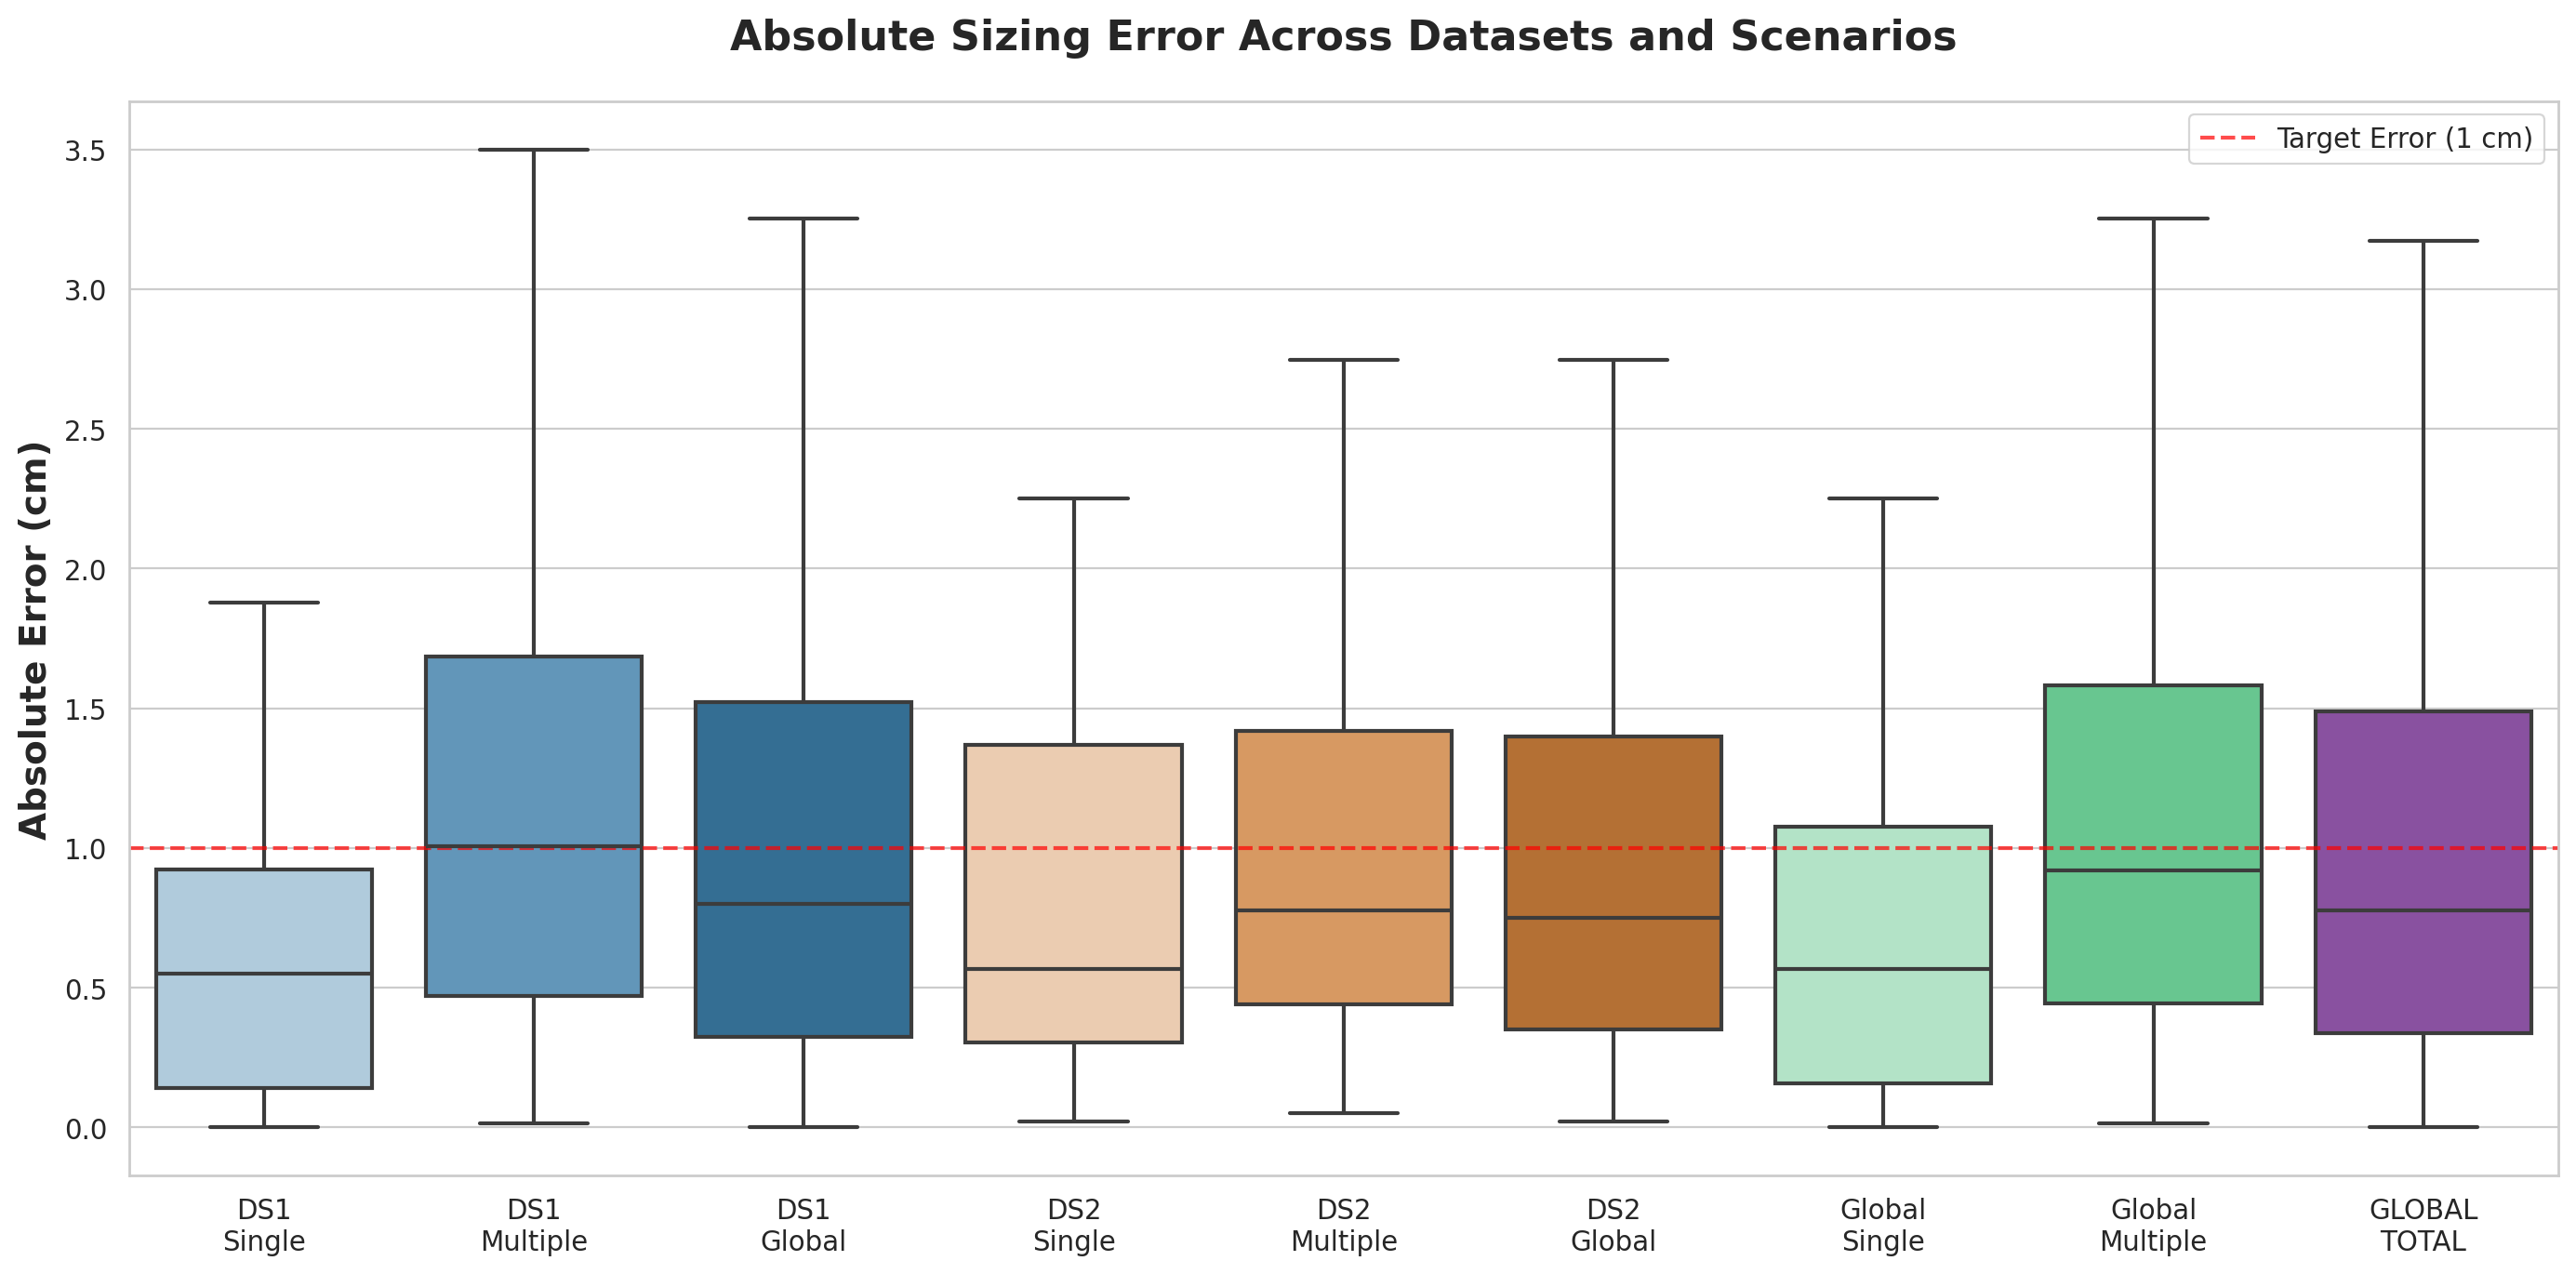


                                   METRICS BY SPECIES (UNIFIED)
SPECIES                        | Total Tracks | Measured   | Success (%)  | MAE (cm)   | STD (cm)   | MAPE (%)  
---------------------------------------------------------------------------------------------------------
Llobarro (D. labrax)           | 367          | 148        | 40.3         | 1.15       | 1.53       | 3.76      
S. scombrus                    | 149          | 74         | 49.7         | 1.00       | 1.24       | 3.44      
Blue Whiting (M. poutassou)    | 93           | 66         | 71.0         | 1.55       | 1.42       | 4.93      
B. boops                       | 49           | 31         | 63.3         | 1.14       | 1.49       | 5.28      
D. sargus                      | 8            | 0          | 0.0          | 0.00       | 0.00       | 0.00      



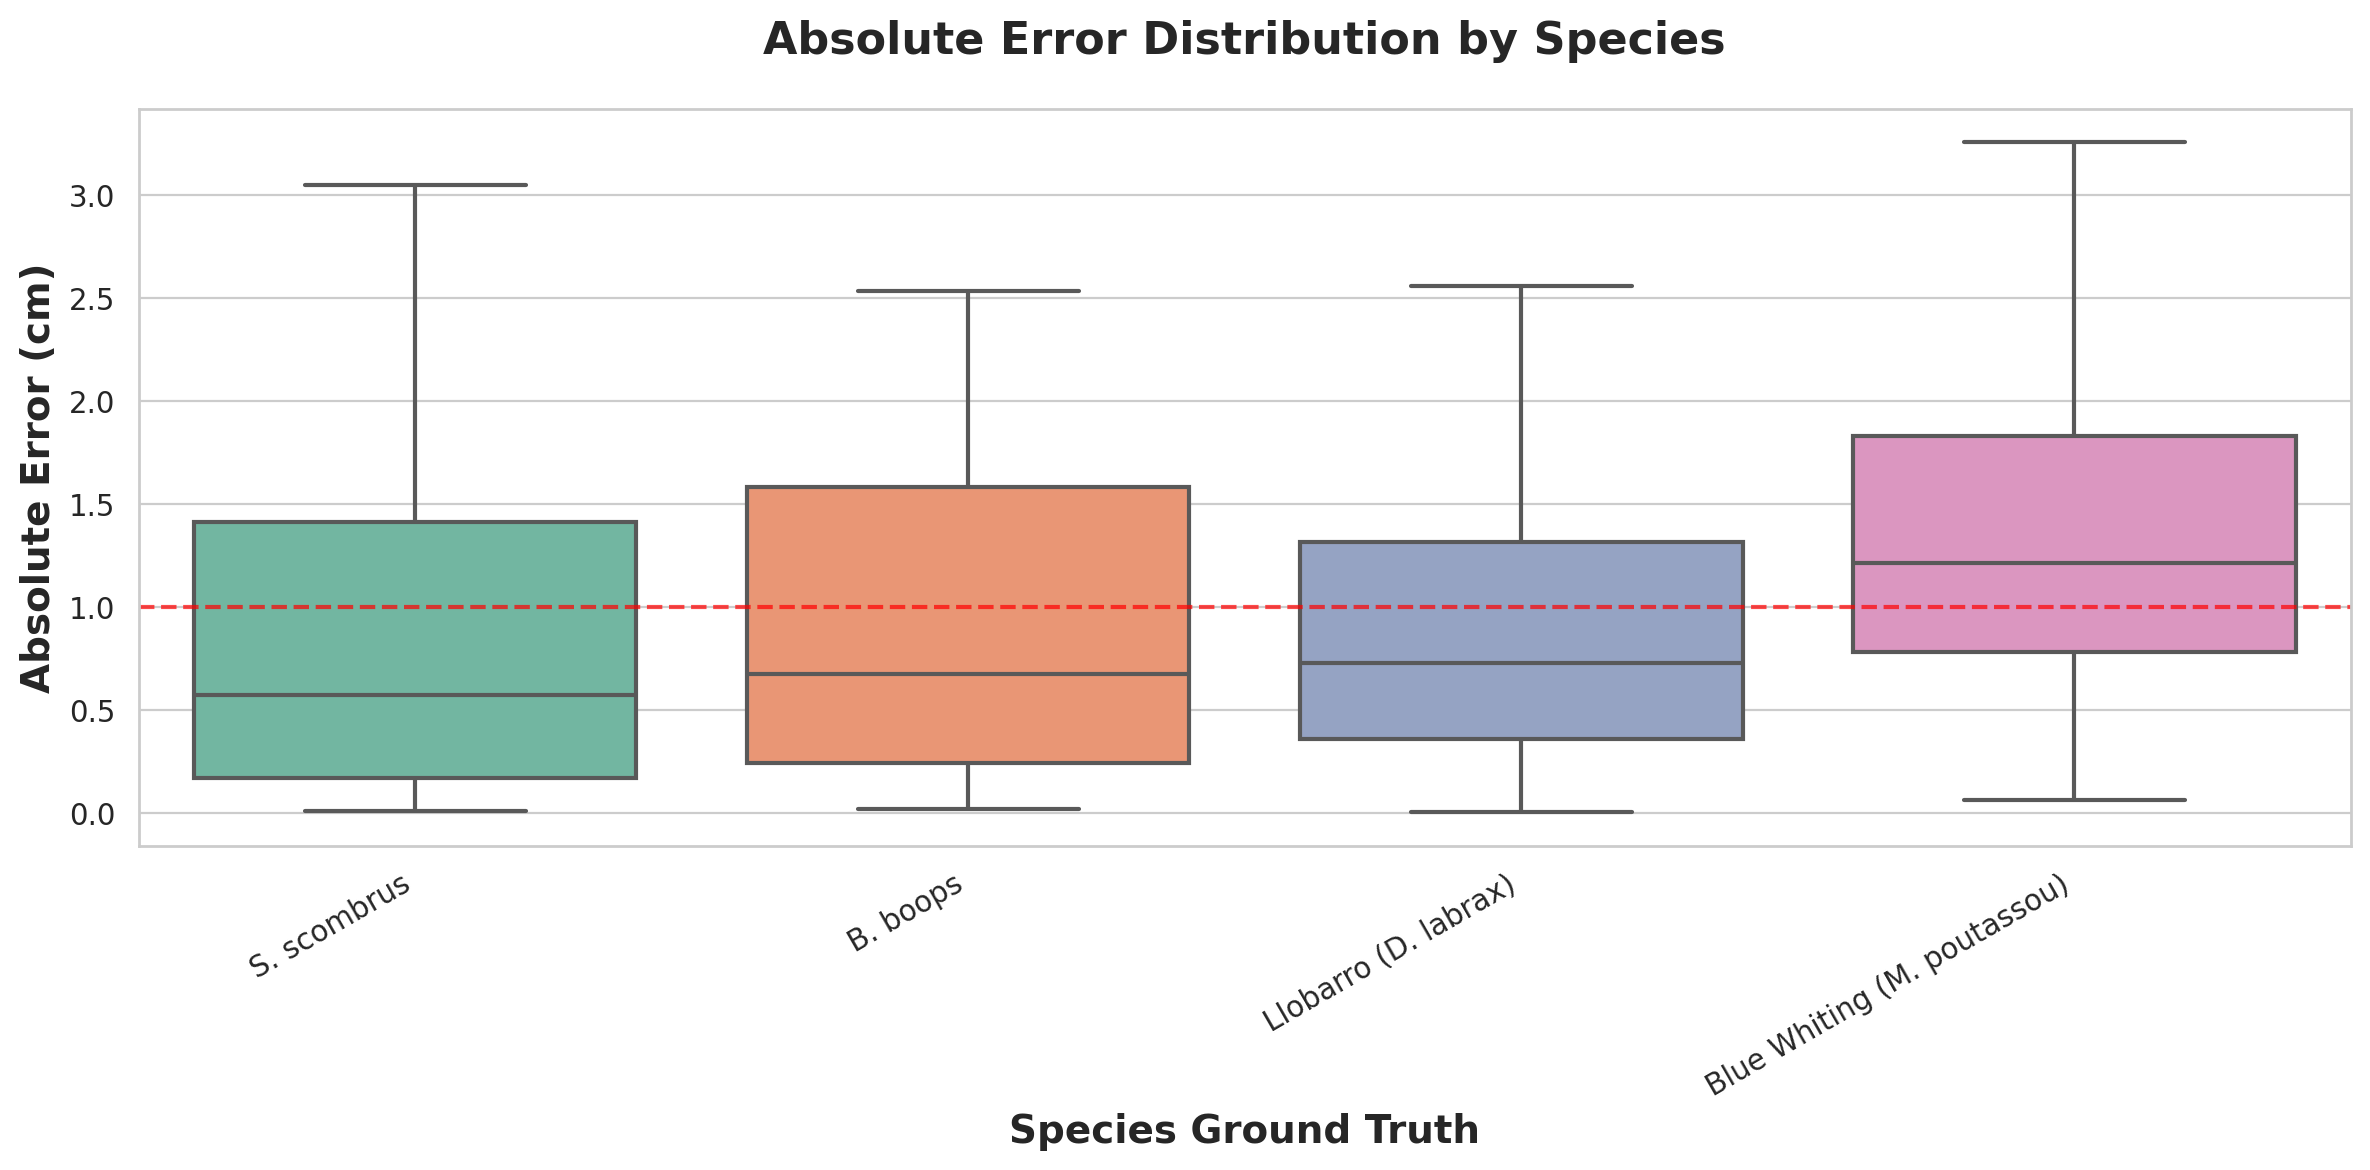

In [46]:

# ===================================================================
# 1. CONFIGURATION & PATHS
# ===================================================================
# Ensure these paths point to where the first script saved the MASTER files
DS1_MASTER_PATH = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_1/aggregated_data/DATASET_1_MASTER_all_fish_all_days.csv")
DS2_MASTER_PATH = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_2/aggregated_data/DATASET_2_MASTER_all_fish_all_days.csv")

# ===================================================================
# 2. DATA LOADING & TRACK AGGREGATION
# ===================================================================
def load_and_filter_dataset(path, dataset_name):
    if not path.exists():
        print(f"⚠️ File not found: {path}")
        return pd.DataFrame(), pd.DataFrame()
        
    df = pd.read_csv(path)
    df['dataset'] = dataset_name
    
    # 0. Quitar los Ground Truth no válidos (errores, etc)
    df = df[df['gt'] > 0].copy()
    
    # Crear ID único por track
    df['track_uid'] = df['dataset'] + "_" + df['video_day'].astype(str) + "_" + df['video_name'].astype(str) + "_" + df['track_id'].astype(str)
    
    total_initial_tracks = df['track_uid'].nunique()
    
    print(f"\n--- Processing {dataset_name} ---")
    print(f"Total raw frames with valid GT: {len(df)}")
    print(f"Total initial tracks: {total_initial_tracks}")
    
    # 1. Filtrado por frames
    track_failures = df.groupby('track_uid').apply(rutils.track_failure_from_frames).rename('track_failure_reason')

    measured_uids = track_failures[track_failures == 'measured'].index
    # df_measured = df[df['track_uid'].isin(measured_uids)].copy()
    
    df_measured = df[
        (df['track_uid'].isin(measured_uids)) & 
        (df['failure_reason'] == 'measured')].copy()
    
    tracks_not_measured = total_initial_tracks - len(measured_uids)
    print(f"Frames belonging to 'measured' tracks: {len(df_measured)}")
    print(f"📉 Tracks descartados por 'track_failure_from_frames': {tracks_not_measured}")
    
    if df_measured.empty:
        print(f"❌ ERROR: Ningún track superó el filtro 'measured'.")
        return pd.DataFrame(), df
    
    # 2. Aplicar smart agg    
    track_metrics = df_measured.groupby('track_uid').apply(rutils.smart_aggregator).dropna(how='all')
                
    tracks_after_agg = len(track_metrics)
    tracks_discarded_by_agg = len(measured_uids) - tracks_after_agg
    print(f"📉 Tracks descartados por 'smart_aggregator': {tracks_discarded_by_agg}")
    
    if track_metrics.empty:
        print(f"❌ ERROR: Todos los tracks fueron descartados por el aggregator.")
        return pd.DataFrame(), df
    
    # 3. Recuperar Metadata
    cols_to_keep = ['dataset', 'scenario', 'video_day', 'video_name']
    if 'especie_gt' in df_measured.columns:
        cols_to_keep.append('especie_gt')
    elif 'fish_id' in df_measured.columns:
        cols_to_keep.append('fish_id')
        
    track_metadata = df_measured.groupby('track_uid').first()[cols_to_keep]
    final_tracks = track_metrics.join(track_metadata).reset_index()
    
    # Porcentaje de error relativo
    final_tracks['rel_error_perc'] = (final_tracks['abs_error_cm'] / final_tracks['gt_cm']) * 100
    
    success_rate = (len(final_tracks) / total_initial_tracks) * 100
    print(f"✅ FINAL RESULT: {len(final_tracks)} independent FISH (tracks) successfully aggregated.")
    print(f"📊 Success Rate: {success_rate:.2f}% ({len(final_tracks)}/{total_initial_tracks} tracks medidos con éxito)")
    
    # GUARDAR EL CSV DE ESTE DATASET
    output_csv_path = path.parent / f"{dataset_name}_FINAL_aggregated_metrics.csv"
    final_tracks.to_csv(output_csv_path, index=False)
    
    # Devolvemos TANTO el final como el RAW (para poder contar los totales luego)
    return final_tracks, df


df_ds1_final, df_ds1_raw = load_and_filter_dataset(DS1_MASTER_PATH, "Dataset_1")
df_ds2_final, df_ds2_raw = load_and_filter_dataset(DS2_MASTER_PATH, "Dataset_2")

df_all = pd.concat([df_ds1_final, df_ds2_final], ignore_index=True)
df_all_raw = pd.concat([df_ds1_raw, df_ds2_raw], ignore_index=True)

if df_all.empty:
    raise ValueError("No data was loaded. Check your paths!")

global_csv_path = "GLOBAL_FINAL_aggregated_metrics.csv"
df_all.to_csv(global_csv_path, index=False)
print(f"\n💾 Guardado CSV GLOBAL con todos los datos en: {global_csv_path}")

# ===================================================================
# 3. CREATING CATEGORIES FOR ANALYSIS & 4. METRICS TABLE
# ===================================================================
plot_data = []
summary_stats = []

def analyze_group(cat_name, dataset=None, scenario=None):
    # 1. Contar los tracks INICIALES desde el df crudo
    mask_raw = pd.Series(True, index=df_all_raw.index)
    if dataset: mask_raw &= (df_all_raw['dataset'] == dataset)
    if scenario: mask_raw &= (df_all_raw['scenario'] == scenario)
    
    sub_raw = df_all_raw[mask_raw]
    total_tracks = sub_raw['track_uid'].nunique() if not sub_raw.empty else 0
    
    # 2. Contar los tracks FINALES (y métricas) desde el df procesado
    mask_final = pd.Series(True, index=df_all.index)
    if dataset: mask_final &= (df_all['dataset'] == dataset)
    if scenario: mask_final &= (df_all['scenario'] == scenario)
    
    sub_final = df_all[mask_final]
    measured_tracks = len(sub_final)
    
    # 3. Calcular métricas si hay datos
    if measured_tracks > 0:
        mae = sub_final['abs_error_cm'].mean()
        std = sub_final['abs_error_cm'].std()
        mape = sub_final['rel_error_perc'].mean()
    else:
        mae = std = mape = 0.0
        
    # Guardar en la lista de resumen para imprimir la tabla luego
    summary_stats.append({
        'Category': cat_name,
        'Total Tracks': total_tracks,
        'Measured Tracks': measured_tracks,
        'MAE': mae,
        'STD': std,
        'MAPE': mape
    })
    
    # Guardar los datos del grupo para el boxplot
    if not sub_final.empty:
        temp = sub_final.copy()
        temp['Analysis_Group'] = cat_name
        plot_data.append(temp)

# Generamos las categorías dinámicamente
analyze_group("DS1\nSingle", dataset='Dataset_1', scenario='single_fish')
analyze_group("DS1\nMultiple", dataset='Dataset_1', scenario='multiple_fish')
analyze_group("DS1\nGlobal", dataset='Dataset_1')

analyze_group("DS2\nSingle", dataset='Dataset_2', scenario='single_fish')
analyze_group("DS2\nMultiple", dataset='Dataset_2', scenario='multiple_fish')
analyze_group("DS2\nGlobal", dataset='Dataset_2')

analyze_group("Global\nSingle", scenario='single_fish')
analyze_group("Global\nMultiple", scenario='multiple_fish')
analyze_group("GLOBAL\nTOTAL")

df_summary = pd.DataFrame(summary_stats)
df_plot = pd.concat(plot_data, ignore_index=True)

# IMPRIMIR LA TABLA FINAL
print("\n" + "="*95)
print(f"{'CATEGORY':<15} | {'Total Tracks':<12} | {'Measured':<10} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
print("-" * 95)

for _, row in df_summary.iterrows():
    group_clean = row['Category'].replace("\n", " ")
    print(f"{group_clean:<15} | {row['Total Tracks']:<12} | {row['Measured Tracks']:<10} | {row['MAE']:<10.2f} | {row['STD']:<10.2f} | {row['MAPE']:<10.2f}")

print("="*95 + "\n")

# ===================================================================
# 5. PUBLICATION-QUALITY BOXPLOT
# ===================================================================
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

palette = [
    "#A9CCE3", "#5499C7", "#2471A3",  # DS1
    "#F5CBA7", "#EB984E", "#CA6F1E",  # DS2
    "#ABEBC6", "#58D68D", "#8E44AD"   # Globals
]

ax = sns.boxplot(
    data=df_plot, 
    x='Analysis_Group', 
    y='abs_error_cm', 
    palette=palette,
    showfliers=False,
    linewidth=1.5
)

plt.title("Absolute Sizing Error Across Datasets and Scenarios", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
plt.xlabel("", fontsize=14) 

plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target Error (1 cm)')
plt.legend()

plt.tight_layout()
plt.savefig("Final_Metrics_Boxplot.png", dpi=300)
plt.show()

# ===================================================================
# 6. METRICS & PLOT BY SPECIES (especie_gt) - UNIFICADO
# ===================================================================
if 'especie_gt' in df_all.columns:
    species_stats = []
    
    # 1. DICCIONARIO DE MAPEO (Traducción a nombres científicos/formales)
    species_mapping = {
        'red': 'Llobarro (D. labrax)',
        'black': 'Llobarro (D. labrax)',
        'no_mark': 'Llobarro (D. labrax)',
        'lubina0': 'Llobarro (D. labrax)',
        'llobarro': 'Llobarro (D. labrax)',
        
        'ochoa_cinta': 'Blue Whiting (M. poutassou)',
        'ochoa_petita': 'Blue Whiting (M. poutassou)',
        'ochoa_no_cinta': 'Blue Whiting (M. poutassou)',
        
        'fish_1': 'D. sargus',
        'fish_3': 'B. boops',
        'caballa': 'S. scombrus'
    }
    
    # 2. APLICAR EL MAPEO A AMBOS DATAFRAMES
    # Rellenamos NaNs primero, luego aplicamos el replace. 
    # Si alguna etiqueta no está en el diccionario, se quedará con su nombre original.
    df_all_raw['especie_gt_clean'] = df_all_raw['especie_gt'].fillna('Unknown').replace(species_mapping)
    df_all['especie_gt_clean'] = df_all['especie_gt'].fillna('Unknown').replace(species_mapping)
    
    # Sacamos las especies únicas ya unificadas
    unique_species = df_all_raw['especie_gt_clean'].unique()
    
    print("\n" + "="*105)
    print(" " * 35 + "METRICS BY SPECIES (UNIFIED)")
    print("="*105)
    print(f"{'SPECIES':<30} | {'Total Tracks':<12} | {'Measured':<10} | {'Success (%)':<12} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
    print("-" * 105)
    
    for species in unique_species:
        # Total tracks crudos para esta especie unificada
        sub_raw = df_all_raw[df_all_raw['especie_gt_clean'] == species]
        total_s_tracks = sub_raw['track_uid'].nunique() if not sub_raw.empty else 0
        
        # Tracks medidos y métricas para esta especie unificada
        sub_final = df_all[df_all['especie_gt_clean'] == species]
        measured_s_tracks = len(sub_final)
        
        if measured_s_tracks > 0:
            mae = sub_final['abs_error_cm'].mean()
            std = sub_final['abs_error_cm'].std()
            mape = sub_final['rel_error_perc'].mean()
        else:
            mae = std = mape = 0.0
            
        success_perc = (measured_s_tracks/total_s_tracks*100) if total_s_tracks > 0 else 0
            
        print(f"{species:<30} | {total_s_tracks:<12} | {measured_s_tracks:<10} | {success_perc:<12.1f} | {mae:<10.2f} | {std:<10.2f} | {mape:<10.2f}")
        
    print("="*105 + "\n")

    # ---- BOXPLOT POR ESPECIE UNIFICADA ----
    if len(df_all) > 0:
        plt.figure(figsize=(12, 6))
        sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
        
        # Ordenamos las especies por la mediana del error
        order = df_all.groupby('especie_gt_clean')['abs_error_cm'].median().sort_values().index
        
        ax2 = sns.boxplot(
            data=df_all, 
            x='especie_gt_clean', 
            y='abs_error_cm', 
            order=order,
            palette="Set2", 
            showfliers=False,
            linewidth=1.5
        )
        
        plt.title("Absolute Error Distribution by Species", fontsize=16, fontweight='bold', pad=20)
        plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
        plt.xlabel("Species Ground Truth", fontsize=14, fontweight='bold')
        
        plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target Error (1 cm)')
        
        # Ajustamos las etiquetas del eje X por si los nombres científicos son largos
        plt.xticks(rotation=30, ha='right') 
        
        # Si usaste paleta 'Set2' o similar sin un 'hue', no hace falta legend() aquí.
        
        plt.tight_layout()
        plt.savefig("Final_Metrics_Boxplot_Species.png", dpi=300)
        plt.show()
else:
    print("⚠️ No 'especie_gt' column found in the dataset. Skipping species analysis.")


--- Processing Dataset_1 ---
Total raw frames with valid GT: 34633
Total initial tracks: 461
Frames belonging to 'measured' tracks: 15155
📉 Tracks descartados por 'track_failure_from_frames': 147
📉 Tracks descartados por 'smart_aggregator': 93
✅ FINAL RESULT: 221 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 47.94% (221/461 tracks medidos con éxito)

--- Processing Dataset_2 ---
Total raw frames with valid GT: 26087
Total initial tracks: 205
Frames belonging to 'measured' tracks: 3266
📉 Tracks descartados por 'track_failure_from_frames': 88
📉 Tracks descartados por 'smart_aggregator': 19
✅ FINAL RESULT: 98 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 47.80% (98/205 tracks medidos con éxito)

💾 Guardado CSV GLOBAL con todos los datos en: GLOBAL_FINAL_aggregated_metrics.csv

                                   GLOBAL METRICS BY SCENARIO
CATEGORY        | Total Tracks | Measured   | Success (%)  | MAE (cm)   | STD (cm)   | MAPE (%)  
------------

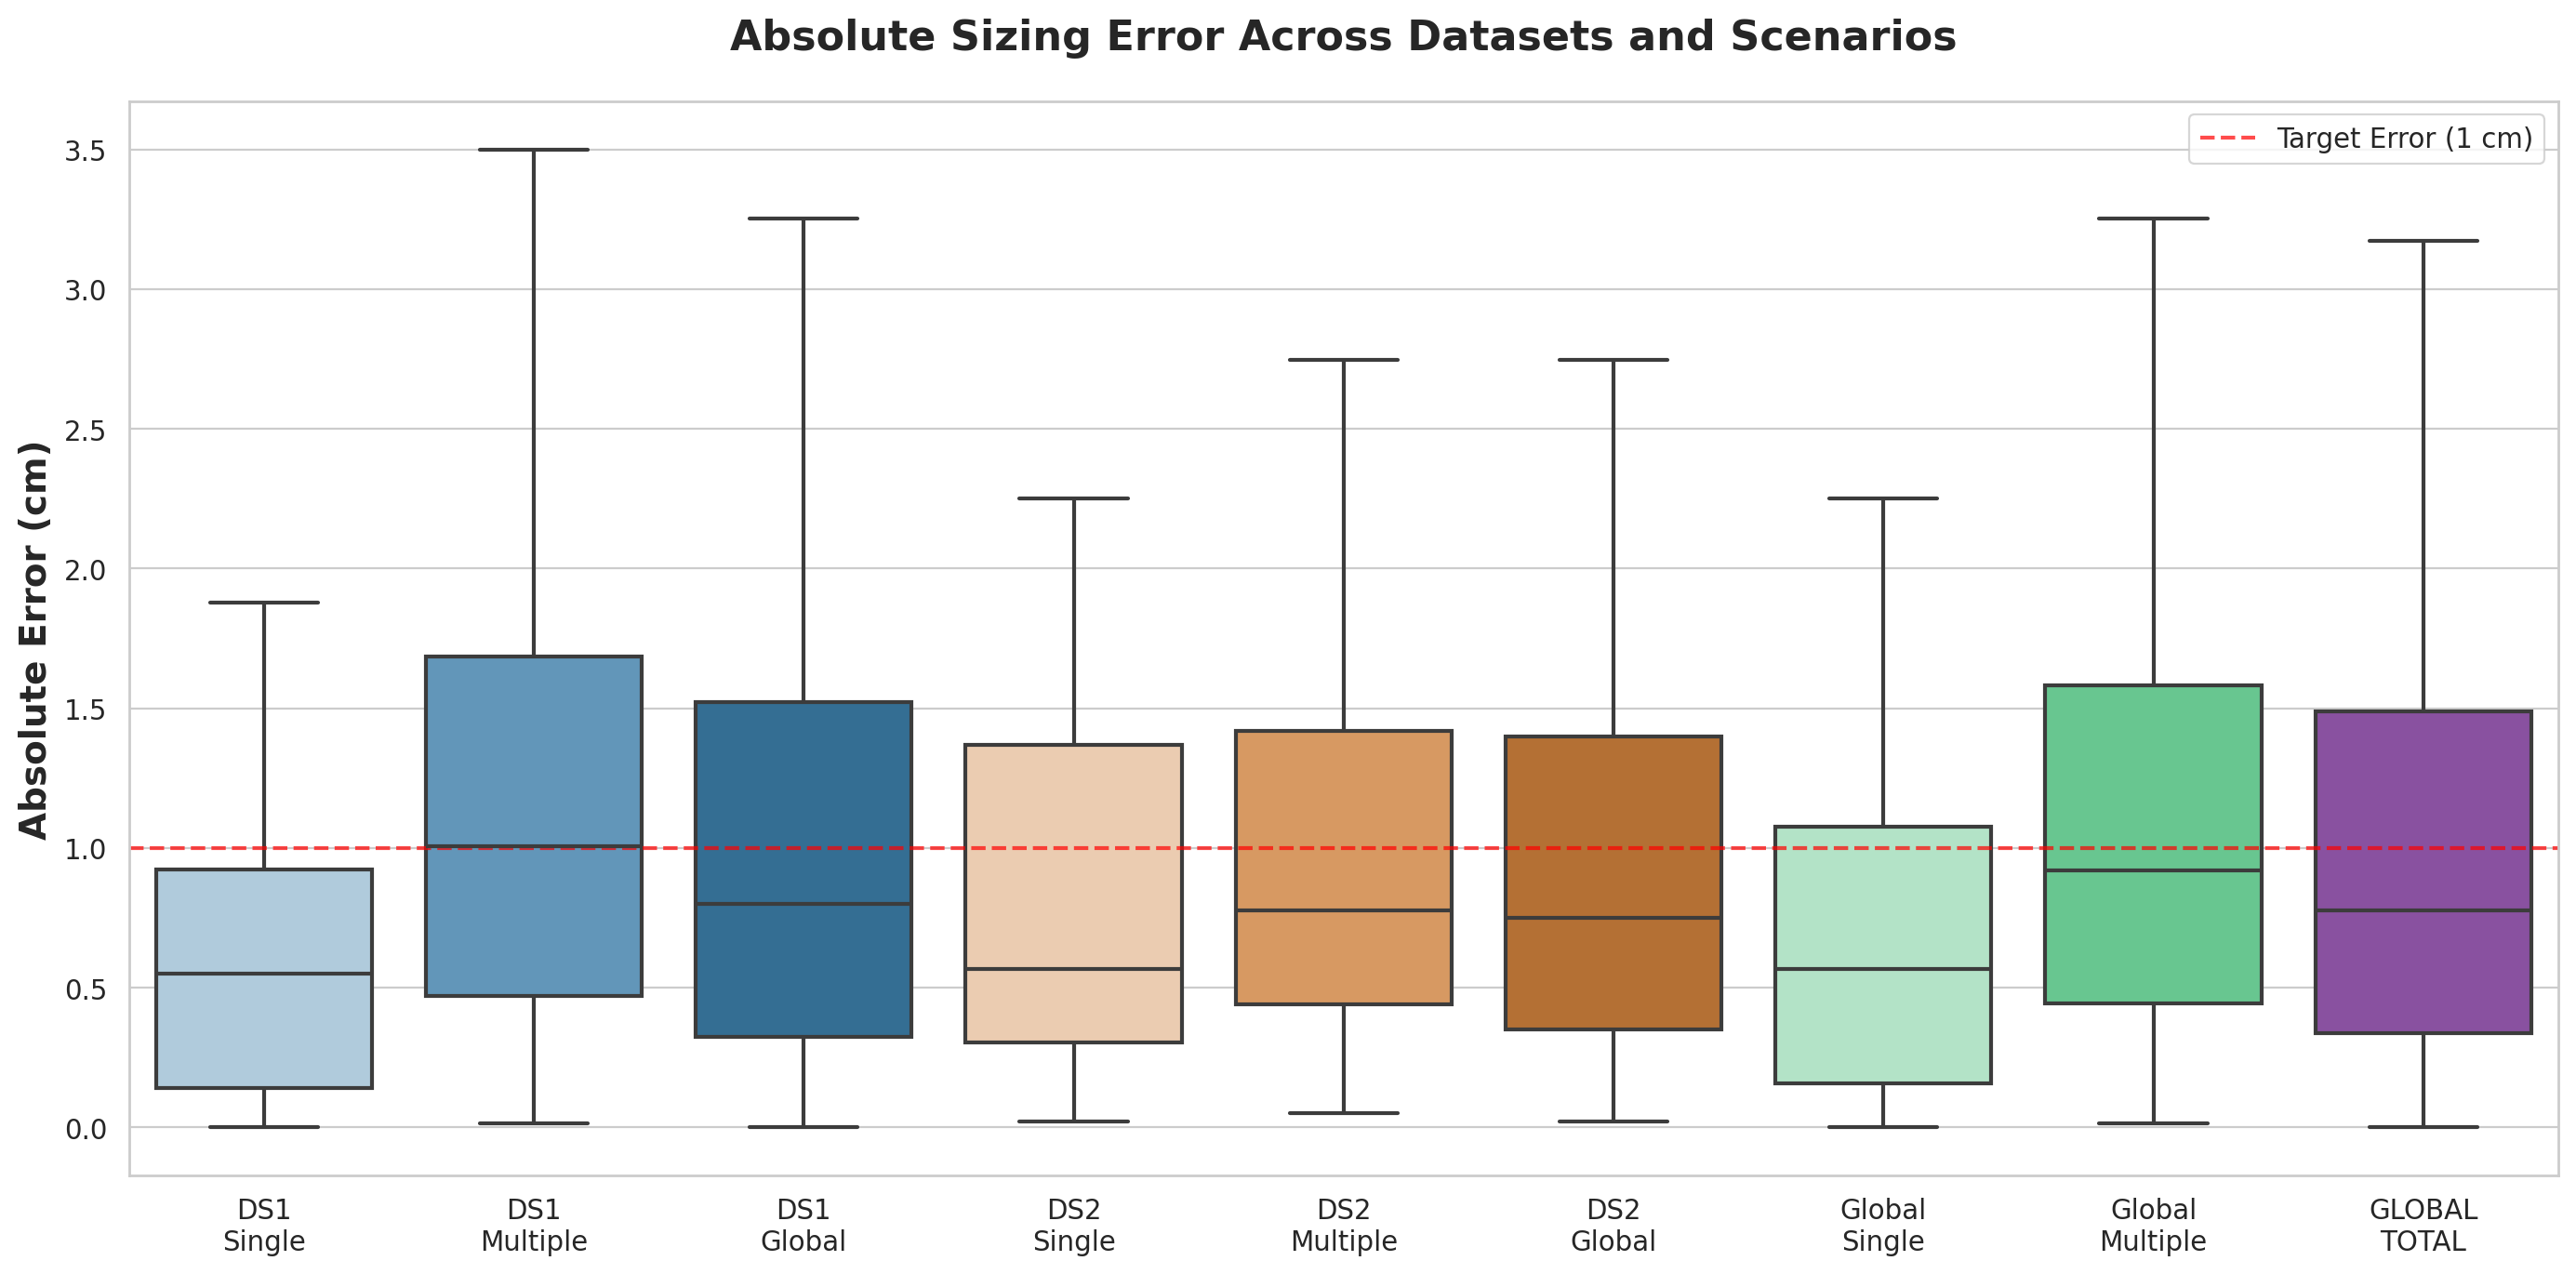


                                        METRICS BY SPECIES
SPECIES              | Total Tracks | Measured   | Success (%)  | MAE (cm)   | STD (cm)   | MAPE (%)  
---------------------------------------------------------------------------------------------------------
lubina0              | 127          | 25         | 19.7         | 0.63       | 0.45       | 2.01      
caballa              | 149          | 74         | 49.7         | 1.00       | 1.24       | 3.44      
ochoa_cinta          | 40           | 21         | 52.5         | 1.75       | 1.05       | 5.22      
fish_3               | 49           | 31         | 63.3         | 1.14       | 1.49       | 5.28      
fish_1               | 8            | 0          | 0.0          | 0.00       | 0.00       | 0.00      
ochoa_petita         | 29           | 25         | 86.2         | 1.44       | 1.90       | 4.74      
llobarro             | 35           | 25         | 71.4         | 1.38       | 1.79       | 4.11      
ochoa_no_c

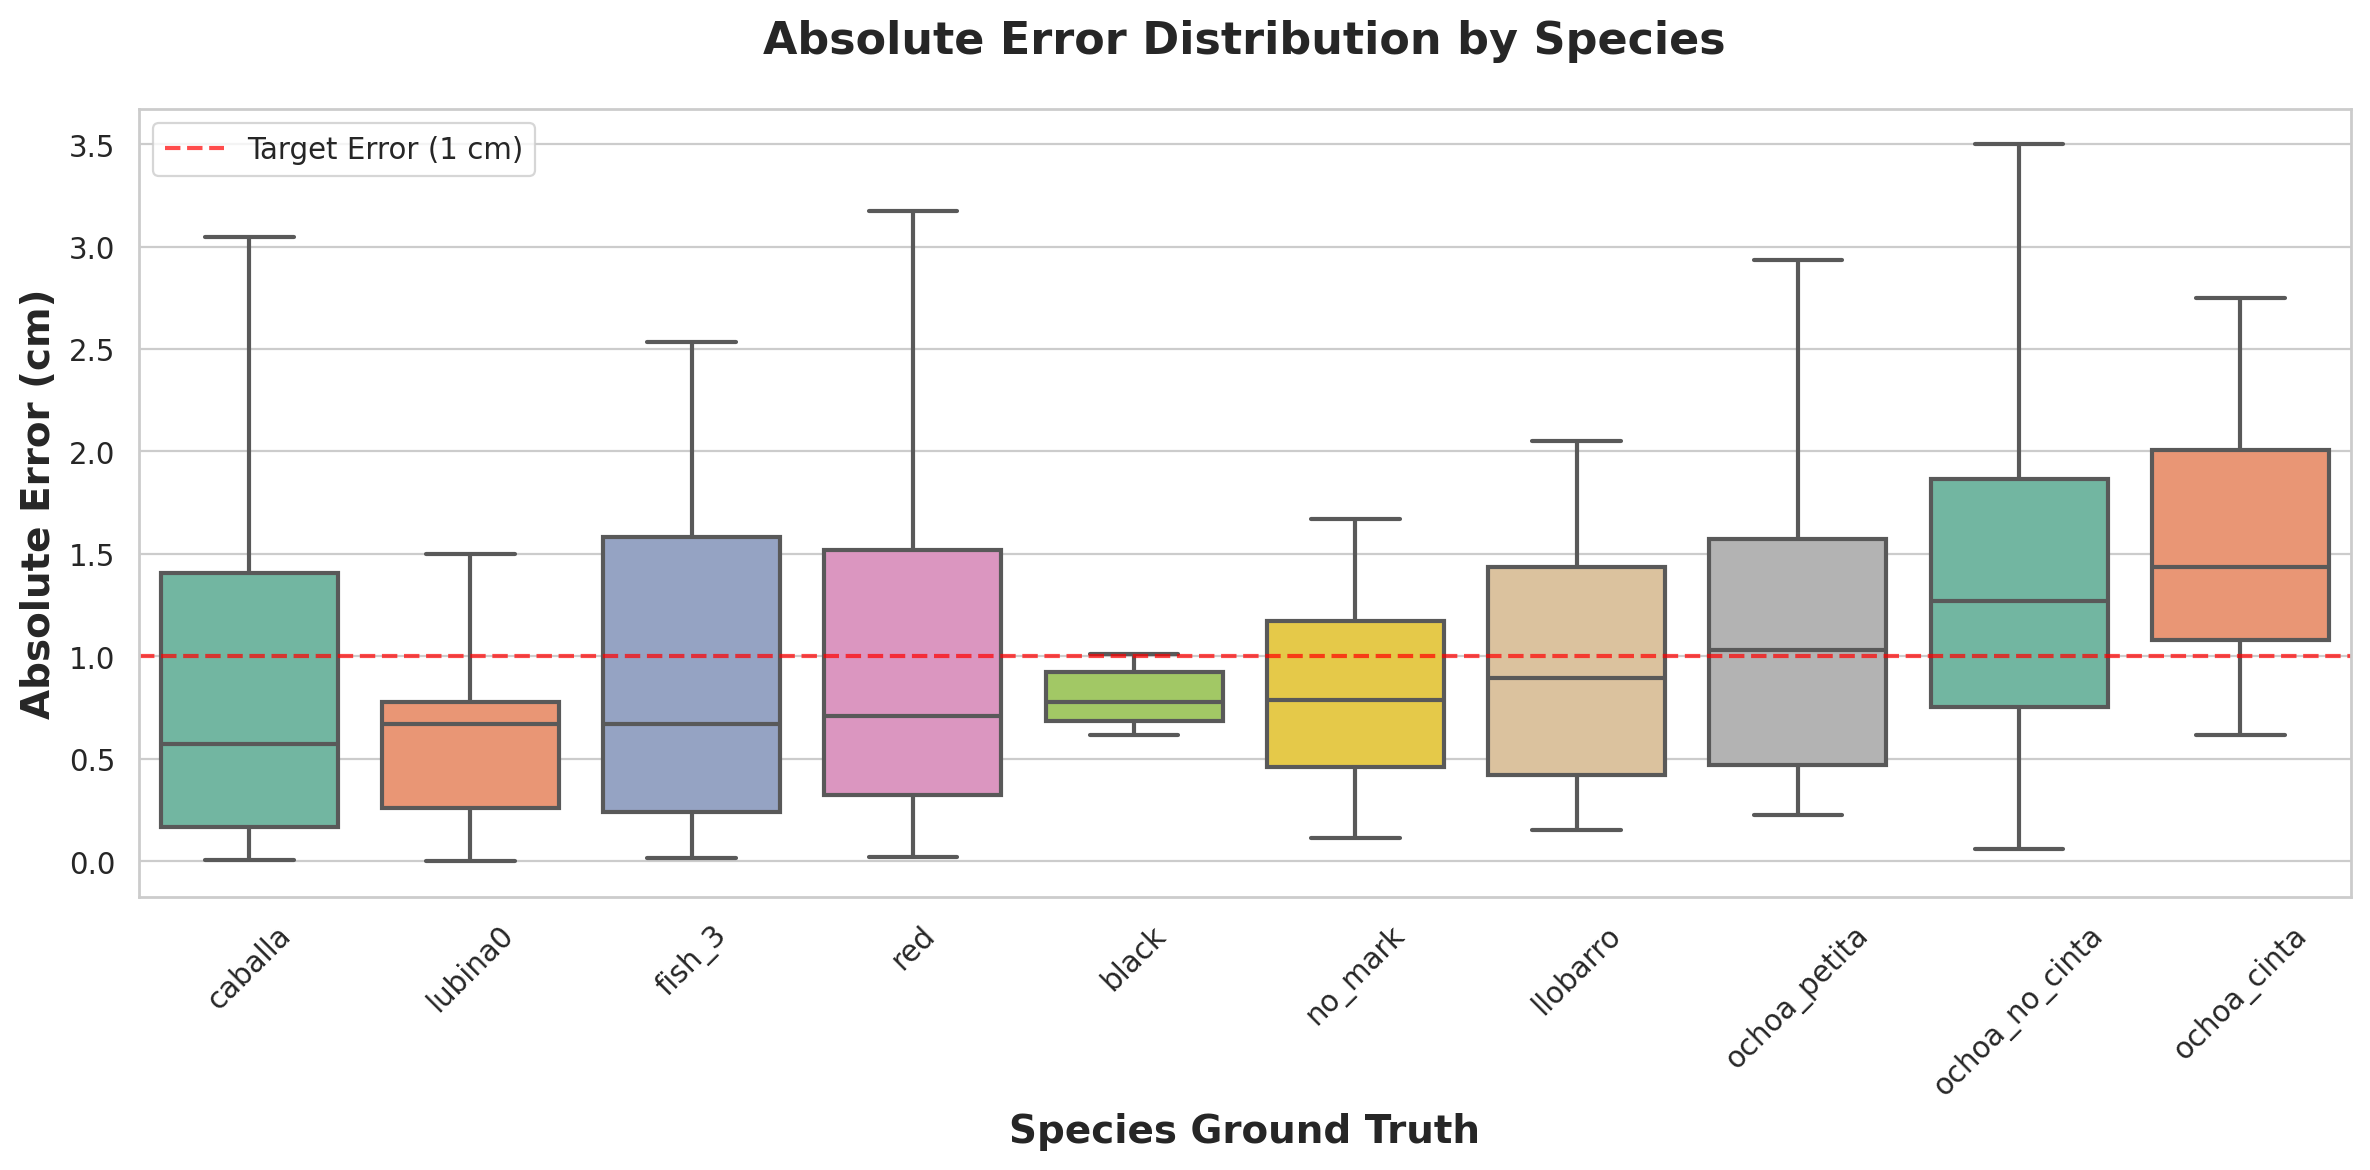

In [47]:


# ===================================================================
# 1. CONFIGURATION & PATHS
# ===================================================================
# Ensure these paths point to where the first script saved the MASTER files
DS1_MASTER_PATH = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_1/aggregated_data/DATASET_1_MASTER_all_fish_all_days.csv")
DS2_MASTER_PATH = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_2/aggregated_data/DATASET_2_MASTER_all_fish_all_days.csv")

# ===================================================================
# 2. DATA LOADING & TRACK AGGREGATION
# ===================================================================
def load_and_filter_dataset(path, dataset_name):
    if not path.exists():
        print(f"⚠️ File not found: {path}")
        return pd.DataFrame(), pd.DataFrame()
        
    df = pd.read_csv(path)
    df['dataset'] = dataset_name
    
    # 0. Quitar los Ground Truth no válidos (errores, etc)
    df = df[df['gt'] > 0].copy()
    
    # Recalculate failure reasons frame by frame using strict thresholds
    # (Assuming ASPECT_RATIO_THR and ANGLE_THR are defined globally)
    df = rutils.assign_failure_reasons(df, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
    
    # Crear ID único por track
    df['track_uid'] = df['dataset'] + "_" + df['video_day'].astype(str) + "_" + df['video_name'].astype(str) + "_" + df['track_id'].astype(str)
    
    total_initial_tracks = df['track_uid'].nunique()
    
    print(f"\n--- Processing {dataset_name} ---")
    print(f"Total raw frames with valid GT: {len(df)}")
    print(f"Total initial tracks: {total_initial_tracks}")
    
    # 1. Filtrado por frames
    track_failures = df.groupby('track_uid').apply(rutils.track_failure_from_frames).rename('track_failure_reason')

    measured_uids = track_failures[track_failures == 'measured'].index
    
    # 🌟 El cambio clave: Solo pasamos los frames perfectos al agregador
    df_measured = df[
        (df['track_uid'].isin(measured_uids)) & 
        (df['failure_reason'] == 'measured')
    ].copy()
    
    tracks_not_measured = total_initial_tracks - len(measured_uids)
    print(f"Frames belonging to 'measured' tracks: {len(df_measured)}")
    print(f"📉 Tracks descartados por 'track_failure_from_frames': {tracks_not_measured}")
    
    if df_measured.empty:
        print(f"❌ ERROR: Ningún track superó el filtro 'measured'.")
        return pd.DataFrame(), df
    
    # 2. Aplicar smart agg    
    track_metrics = df_measured.groupby('track_uid').apply(rutils.smart_aggregator).dropna(how='all')
                
    tracks_after_agg = len(track_metrics)
    tracks_discarded_by_agg = len(measured_uids) - tracks_after_agg
    print(f"📉 Tracks descartados por 'smart_aggregator': {tracks_discarded_by_agg}")
    
    if track_metrics.empty:
        print(f"❌ ERROR: Todos los tracks fueron descartados por el aggregator.")
        return pd.DataFrame(), df
    
    # 3. Recuperar Metadata
    cols_to_keep = ['dataset', 'scenario', 'video_day', 'video_name']
    if 'especie_gt' in df_measured.columns:
        cols_to_keep.append('especie_gt')
    elif 'fish_id' in df_measured.columns:
        cols_to_keep.append('fish_id')
        
    track_metadata = df_measured.groupby('track_uid').first()[cols_to_keep]
    final_tracks = track_metrics.join(track_metadata).reset_index()
    
    # Porcentaje de error relativo
    final_tracks['rel_error_perc'] = (final_tracks['abs_error_cm'] / final_tracks['gt_cm']) * 100
    
    success_rate = (len(final_tracks) / total_initial_tracks) * 100 if total_initial_tracks > 0 else 0
    print(f"✅ FINAL RESULT: {len(final_tracks)} independent FISH (tracks) successfully aggregated.")
    print(f"📊 Success Rate: {success_rate:.2f}% ({len(final_tracks)}/{total_initial_tracks} tracks medidos con éxito)")
    
    # GUARDAR EL CSV DE ESTE DATASET
    output_csv_path = path.parent / f"{dataset_name}_FINAL_aggregated_metrics.csv"
    final_tracks.to_csv(output_csv_path, index=False)
    
    # Devolvemos TANTO el final como el RAW
    return final_tracks, df


df_ds1_final, df_ds1_raw = load_and_filter_dataset(DS1_MASTER_PATH, "Dataset_1")
df_ds2_final, df_ds2_raw = load_and_filter_dataset(DS2_MASTER_PATH, "Dataset_2")

df_all = pd.concat([df_ds1_final, df_ds2_final], ignore_index=True)
df_all_raw = pd.concat([df_ds1_raw, df_ds2_raw], ignore_index=True)

if df_all.empty:
    raise ValueError("No data was loaded. Check your paths!")

global_csv_path = "GLOBAL_FINAL_aggregated_metrics.csv"
df_all.to_csv(global_csv_path, index=False)
print(f"\n💾 Guardado CSV GLOBAL con todos los datos en: {global_csv_path}")

# ===================================================================
# 3. CREATING CATEGORIES FOR ANALYSIS & 4. METRICS TABLE
# ===================================================================
plot_data = []
summary_stats = []

def analyze_group(cat_name, dataset=None, scenario=None):
    mask_raw = pd.Series(True, index=df_all_raw.index)
    if dataset: mask_raw &= (df_all_raw['dataset'] == dataset)
    if scenario: mask_raw &= (df_all_raw['scenario'] == scenario)
    
    sub_raw = df_all_raw[mask_raw]
    total_tracks = sub_raw['track_uid'].nunique() if not sub_raw.empty else 0
    
    mask_final = pd.Series(True, index=df_all.index)
    if dataset: mask_final &= (df_all['dataset'] == dataset)
    if scenario: mask_final &= (df_all['scenario'] == scenario)
    
    sub_final = df_all[mask_final]
    measured_tracks = len(sub_final)
    
    if measured_tracks > 0:
        mae = sub_final['abs_error_cm'].mean()
        std = sub_final['abs_error_cm'].std()
        mape = sub_final['rel_error_perc'].mean()
    else:
        mae = std = mape = 0.0
        
    summary_stats.append({
        'Category': cat_name,
        'Total Tracks': total_tracks,
        'Measured Tracks': measured_tracks,
        'Success Rate (%)': (measured_tracks/total_tracks*100) if total_tracks > 0 else 0,
        'MAE': mae,
        'STD': std,
        'MAPE': mape
    })
    
    if not sub_final.empty:
        temp = sub_final.copy()
        temp['Analysis_Group'] = cat_name
        plot_data.append(temp)

analyze_group("DS1\nSingle", dataset='Dataset_1', scenario='single_fish')
analyze_group("DS1\nMultiple", dataset='Dataset_1', scenario='multiple_fish')
analyze_group("DS1\nGlobal", dataset='Dataset_1')
analyze_group("DS2\nSingle", dataset='Dataset_2', scenario='single_fish')
analyze_group("DS2\nMultiple", dataset='Dataset_2', scenario='multiple_fish')
analyze_group("DS2\nGlobal", dataset='Dataset_2')
analyze_group("Global\nSingle", scenario='single_fish')
analyze_group("Global\nMultiple", scenario='multiple_fish')
analyze_group("GLOBAL\nTOTAL")

df_summary = pd.DataFrame(summary_stats)
df_plot = pd.concat(plot_data, ignore_index=True)

print("\n" + "="*105)
print(" " * 35 + "GLOBAL METRICS BY SCENARIO")
print("="*105)
print(f"{'CATEGORY':<15} | {'Total Tracks':<12} | {'Measured':<10} | {'Success (%)':<12} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
print("-" * 105)

for _, row in df_summary.iterrows():
    group_clean = row['Category'].replace("\n", " ")
    print(f"{group_clean:<15} | {row['Total Tracks']:<12} | {row['Measured Tracks']:<10} | {row['Success Rate (%)']:<12.1f} | {row['MAE']:<10.2f} | {row['STD']:<10.2f} | {row['MAPE']:<10.2f}")
print("="*105 + "\n")

# ===================================================================
# 5. PUBLICATION-QUALITY BOXPLOT (SCENARIOS)
# ===================================================================
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

palette = ["#A9CCE3", "#5499C7", "#2471A3", "#F5CBA7", "#EB984E", "#CA6F1E", "#ABEBC6", "#58D68D", "#8E44AD"]

ax = sns.boxplot(
    data=df_plot, x='Analysis_Group', y='abs_error_cm', palette=palette, showfliers=False, linewidth=1.5
)
plt.title("Absolute Sizing Error Across Datasets and Scenarios", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
plt.xlabel("") 
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target Error (1 cm)')
plt.legend()
plt.tight_layout()
plt.savefig("Final_Metrics_Boxplot_Scenarios.png", dpi=300)
plt.show()

# ===================================================================
# 6. METRICS & PLOT BY SPECIES (especie_gt)
# ===================================================================
if 'especie_gt' in df_all.columns:
    species_stats = []
    
    # Rellenar NaNs por si alguna fila no tiene especie
    df_all_raw['especie_gt'] = df_all_raw['especie_gt'].fillna('Unknown')
    df_all['especie_gt'] = df_all['especie_gt'].fillna('Unknown')
    
    unique_species = df_all_raw['especie_gt'].unique()
    
    print("\n" + "="*105)
    print(" " * 40 + "METRICS BY SPECIES")
    print("="*105)
    print(f"{'SPECIES':<20} | {'Total Tracks':<12} | {'Measured':<10} | {'Success (%)':<12} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
    print("-" * 105)
    
    for species in unique_species:
        # Total tracks crudos para esta especie
        sub_raw = df_all_raw[df_all_raw['especie_gt'] == species]
        total_s_tracks = sub_raw['track_uid'].nunique() if not sub_raw.empty else 0
        
        # Tracks medidos y métricas
        sub_final = df_all[df_all['especie_gt'] == species]
        measured_s_tracks = len(sub_final)
        
        if measured_s_tracks > 0:
            mae = sub_final['abs_error_cm'].mean()
            std = sub_final['abs_error_cm'].std()
            mape = sub_final['rel_error_perc'].mean()
        else:
            mae = std = mape = 0.0
            
        success_perc = (measured_s_tracks/total_s_tracks*100) if total_s_tracks > 0 else 0
            
        print(f"{species:<20} | {total_s_tracks:<12} | {measured_s_tracks:<10} | {success_perc:<12.1f} | {mae:<10.2f} | {std:<10.2f} | {mape:<10.2f}")
        
    print("="*105 + "\n")

    # ---- BOXPLOT POR ESPECIE ----
    if len(df_all) > 0:
        plt.figure(figsize=(12, 6))
        sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
        
        # Ordenamos las especies por la mediana del error para que quede visualmente más claro
        order = df_all.groupby('especie_gt')['abs_error_cm'].median().sort_values().index
        
        ax2 = sns.boxplot(
            data=df_all, 
            x='especie_gt', 
            y='abs_error_cm', 
            order=order,
            palette="Set2", # Puedes cambiar la paleta si lo deseas
            showfliers=False,
            linewidth=1.5
        )
        
        plt.title("Absolute Error Distribution by Species", fontsize=16, fontweight='bold', pad=20)
        plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
        plt.xlabel("Species Ground Truth", fontsize=14, fontweight='bold')
        
        plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target Error (1 cm)')
        plt.xticks(rotation=45) # Rotamos las etiquetas por si los nombres de especies son largos
        plt.legend()
        
        plt.tight_layout()
        plt.savefig("Final_Metrics_Boxplot_Species.png", dpi=300)
        plt.show()
else:
    print("⚠️ No 'especie_gt' column found in the dataset. Skipping species analysis.")


📊 Analyzing global track failure causes (Strict Pipeline)...


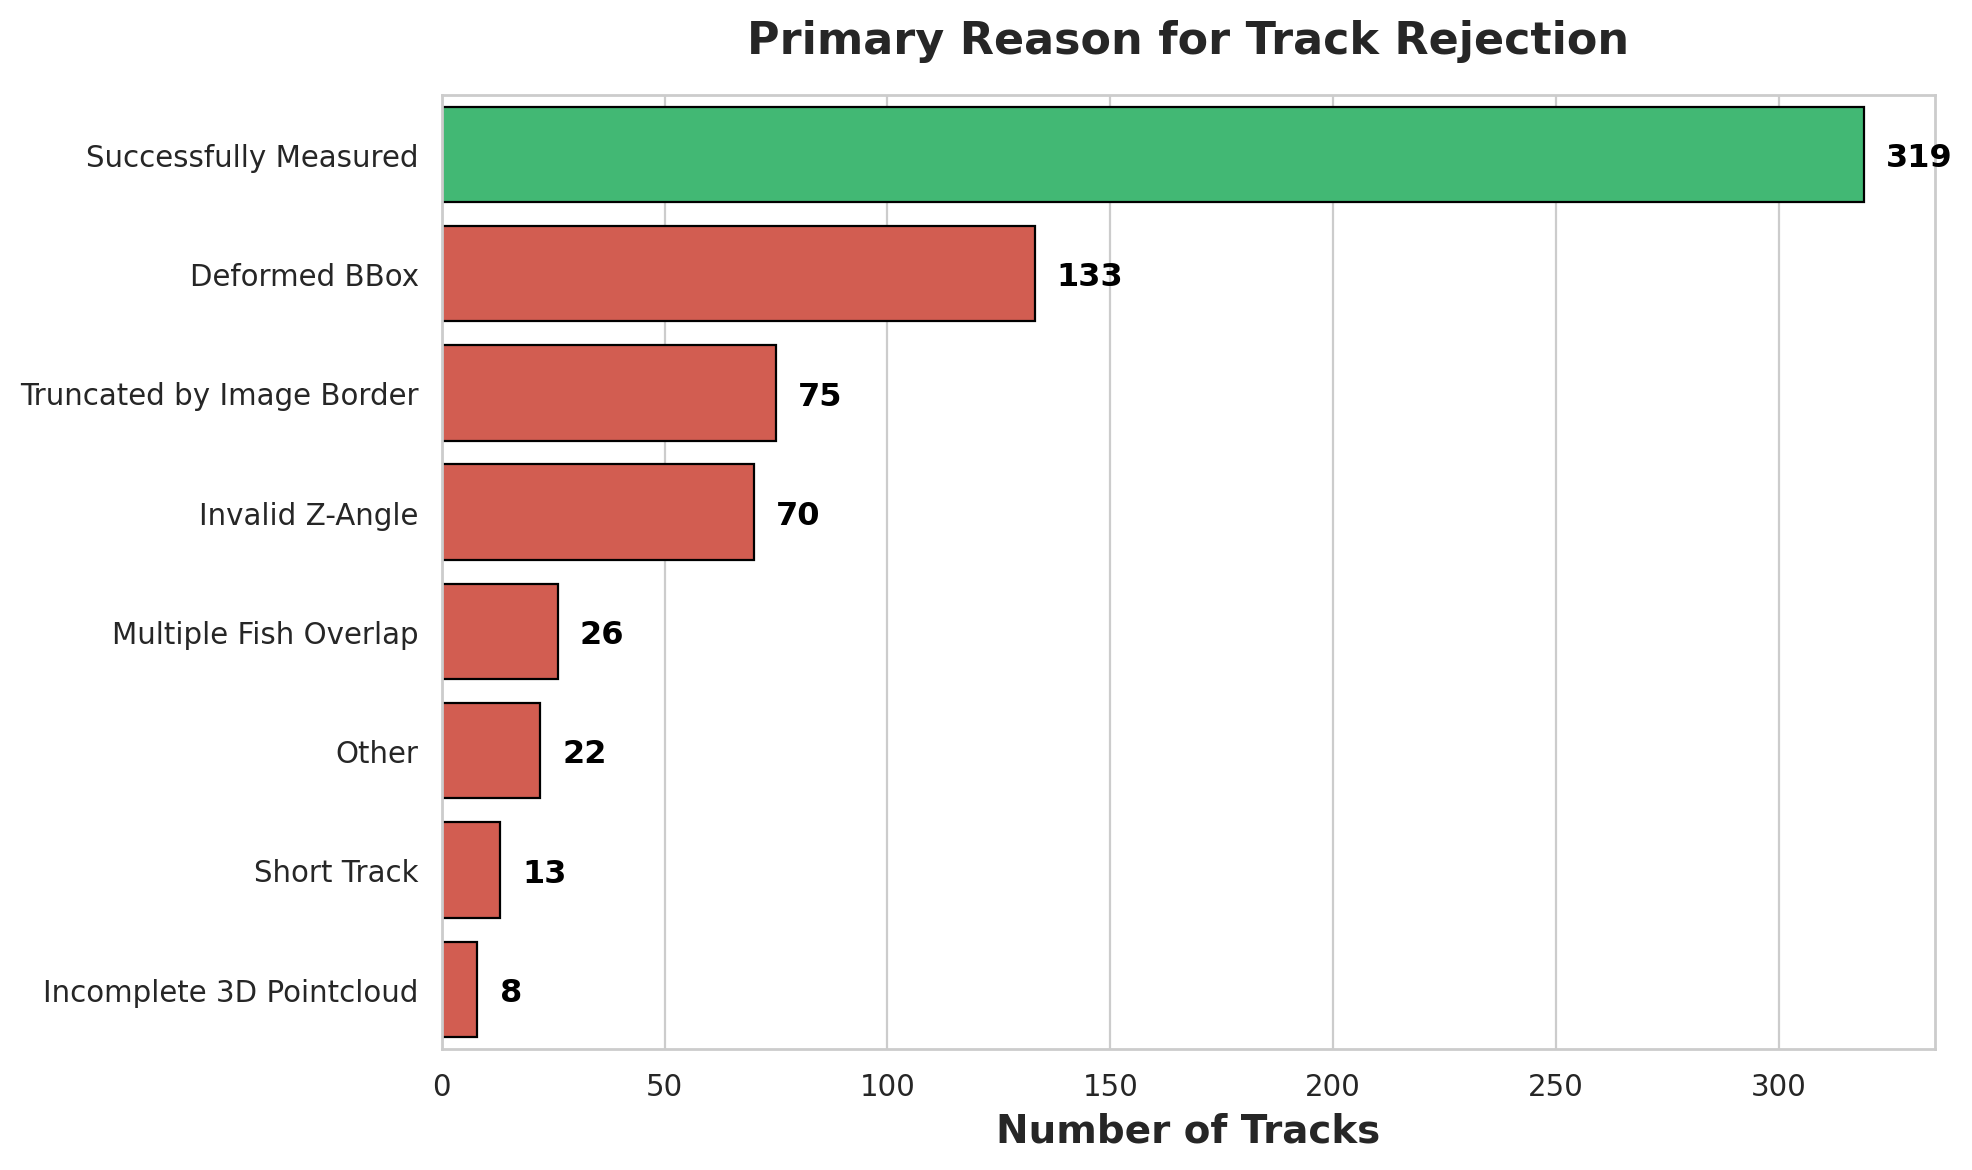


=== STRICT PIPELINE TRACK FAILURE SUMMARY ===
           Failure Reason  Number of Tracks
    Successfully Measured               319
            Deformed BBox               133
Truncated by Image Border                75
          Invalid Z-Angle                70
    Multiple Fish Overlap                26
                    Other                22
              Short Track                13
 Incomplete 3D Pointcloud                 8


In [52]:
# ===================================================================
# 7. GLOBAL TRACK FAILURE CAUSES ANALYSIS (STRICT PIPELINE)
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def get_primary_track_failure(track_df, min_frames=5):
    # 1. Contamos cuántos frames perfectos tiene el track
    measured_count = (track_df['failure_reason'] == 'measured').sum()
    
    # 2. Si supera tu umbral del smart_aggregator, entonces SÍ es un éxito
    if measured_count > min_frames:
        return 'measured'
    
    # 3. Si NO supera el umbral, el track se ha descartado. 
    # ¿De qué ha muerto? Miramos los frames que no son perfectos para ver el error predominante.
    bad_frames = track_df[track_df['failure_reason'] != 'measured']
    
    if bad_frames.empty:
        # Si no hay frames malos, significa que todos sus frames eran perfectos, 
        # pero simplemente el pez pasó tan rápido que no llegó a los 6 frames.
        return 'short_track'
    
    # Devolvemos el error MÁS FRECUENTE (la moda) en los frames descartados de este pez
    return bad_frames['failure_reason'].mode()[0]

print("\n📊 Analyzing global track failure causes (Strict Pipeline)...")

# Agrupamos el dataframe global CRUDO por track_uid y sacamos la causa de fallo
global_track_failures = df_all_raw.groupby('track_uid').apply(get_primary_track_failure)

# Contamos cuántos tracks cayeron por cada motivo
failure_counts = global_track_failures.value_counts()

# Preparamos los datos para el plot
plot_df = failure_counts.reset_index()
plot_df.columns = ['Failure Reason', 'Number of Tracks']

# Mapeamos los nombres para que queden más formales en el artículo
reason_labels = {
    'measured': 'Successfully Measured',
    'short_track': 'Short Track',
    'angle_fail': 'Invalid Z-Angle',
    'aspect_ratio_fail': 'Deformed BBox',
    'overlap': 'Multiple Fish Overlap',
    'borders': 'Truncated by Image Border',
    'incomplete_3D': 'Incomplete 3D Pointcloud',
    'not_a_fish': 'False Positive (Not a Fish)',
    'other': 'Other'
}
plot_df['Failure Reason'] = plot_df['Failure Reason'].map(reason_labels).fillna(plot_df['Failure Reason'])

# ----------------- PLOT: BARRAS HORIZONTALES -----------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Definir colores: Verde para el éxito, gris para short track, rojos/naranjas para fallos de filtro
def get_color(reason):
    if reason == 'Successfully Measured': return '#2ECC71' # Verde
    if reason == 'Short Track (≤ 5 valid frames)': return '#95A5A6' # Gris
    return '#E74C3C' # Rojo para los descartes por filtros

colors = [get_color(r) for r in plot_df['Failure Reason']]

ax = sns.barplot(
    data=plot_df, 
    x='Number of Tracks', 
    y='Failure Reason', 
    palette=colors,
    edgecolor='black'
)

plt.title("Primary Reason for Track Rejection", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Tracks", fontsize=14, fontweight='bold')
plt.ylabel("")

# Añadir los números al final de cada barra
for i, v in enumerate(plot_df['Number of Tracks']):
    ax.text(v + 5, i + 0.1, str(v), color='black', fontweight='bold')

plt.tight_layout()
plt.savefig("Global_Failure_Causes_Strict_Barplot.png", dpi=300)
plt.show()

# Imprimir por consola para validar
print("\n=== STRICT PIPELINE TRACK FAILURE SUMMARY ===")
print(plot_df.to_string(index=False))